# Cap. 1: Configuración y Carga de Datos

Este capítulo inicial sienta las bases para el procesamiento de tus datos, estableciendo el entorno y cargando los conjuntos de datos principales.

🛠️ Paso 0: Configuración y Funciones Maestras

En esta sección, se preparan las herramientas necesarias para la manipulación y análisis de datos.

**• Importación de Librerías:**


*   pandas (pd):
Esencial para la manipulación y análisis de datos tabulares, como DataFrames.

*   numpy (np):
Proporciona soporte para arreglos y matrices, y funciones matemáticas de alto nivel.


*   glob:
Permite encontrar rutas de archivo que coinciden con un patrón específico, útil para la carga masiva.

*   os:
Proporciona funciones para interactuar con el sistema operativo, como la manipulación de rutas de archivos.


*   re:
Ofrece operaciones con expresiones regulares, útil para la búsqueda y manipulación de cadenas de texto.

*   matplotlib.pyplot (plt):
 Biblioteca para la creación de visualizaciones estáticas e interactivas.


*   seaborn (sns):
Basada en matplotlib, ofrece una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.


## **1.1 Confg. Variables**

Se definen dos listas cruciales para estructurar y transformar los datos

*   VARIABLES:
Esta lista enummatplotlib`, ofrece una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.

Se definen dos listas cruciales para estructurar y transformar los datos


*   VARIABLES:

Esta lista enumera las columnas o campos esperados en tus datos. Incluye información como "Municipio", "Red_Afectada", diferentes tipos de fechas y horas ("Fecha_Entrada", "Hora_Entrada", "Fecha_Hora_de_Control", etc.), características de las roturas ("Diametro", "Tipo_Rotura", "Circular", "Largo", "Ancho", "Malla"), detalles del gas ("Gas_Fugado", "Flujo del gas", "Presion"), y otros identificadores como "mes_numero" y "Filial". Estas son las variables clave que se esperan analizar.

*   VARIABLES_A_TRANSFORMAR
Esta lista especifica un subconjunto de las VARIABLES que requerirán una transformación posterior, probablemente a formatos de fecha y hora adecuados, como "Fecha_Entrada", "Fecha_Hora_de_Control", "Fecha_Hora_de_Finalización", entre otras temporales.

## ** 1.2 carga y Unificación**

Esta es la parte central del capítulo, donde se cargan y combinan los datos de las fuentes, incluyendo **data_consolidado.xlsx** y **data_consolidado2.xlsx.**

• Ruta y Archivos: Se define una ruta_archivos que utiliza un patrón (/content/Data_Exp/data_consolidado*.xlsx).

Esto permite que el código identifique automáticamente todos los archivos Excel que comiencen con "data_consolidado" en esa ubicación específicamente, esto incluiría archivos como data_consolidado.xlsx y data_consolidado2.xlsx si sus nombres coinciden con el patrón.

*   Proceso de Carga en Bucle
El código itera sobre cada archivo encontrado

*   pd.read_excel(archivo)
Lee el contenido de cada archivo Excel (como data_consolidado.xlsx y data_consolidado2.xlsx) en un DataFrame temporal.
*   reset_index().rename(columns={'index': 'ID_Original'}):
Añade una columna ID_Original que parece ser un índice único para cada registro dentro de su archivo de origen.

*   df_temp['Archivo_Origen'] = nombre_archivo:

Incorpora el nombre del archivo de origen en una nueva columna Archivo_Origen, lo cual es muy útil para la trazabilidad y para saber de dónde proviene cada fila de datos (por ejemplo, si viene de data_consolidado.xlsx o data_consolidado2.xlsx).


*   Diagnóstico Inicial (Melt):
Se realiza un paso de diagnóstico temprano utilizando df_temp.melt(). Esto transforma el DataFrame temporal para tener una columna Variable y una columna Valor_Original. Se evalúa si cada Valor_Original está **'Vacio'** o **'Lleno'** después de limpiar valores como nan, None o cadenas vacías.

Esta es una excelente manera de obtener una visión rápida de la completitud de los datos por columna en cada archivo.

*   Unificación de Datos:


• lista_master_limpia y lista_diagnosticos: Almacenan los DataFrames procesados y los DataFrames de diagnóstico, respectivamente, de cada archivo

• pd.concat(lista_master_limpia, ignore_index=True): Combina todos los DataFrames individuales de los archivos (como data_consolidado.xlsx y data_consolidado2.xlsx) en un único DataFrame final llamado df_final_total. Esto crea tu conjunto de datos maestro consolidado.

•pd.concat(lista_diagnosticos, ignore_index=True): De manera similar, unifica todos los diagnósticos de vacío en df_diag_total, permitiendo una visión global de los datos faltantes.

• Confirmación: Finalmente, se imprime el total de registros cargados en df_final_total, ofreciendo una confirmación del volumen de datos procesado

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1.1 CONFIGURACIÓN DE VARIABLES ---
VARIABLES = [
    "Municipio", "Red_Afectada", "Fecha_Entrada", "Hora_Entrada",
    "Hora_de_Control", "Hora_de_Finalización", "Fecha_Hora_de_Control",
    "Fecha_Hora_de_Finalización", "Tiempo_Control", "HoraC", "Diametro",
    "Tipo_Rotura", "Circular", "Largo", "Ancho", "Malla", "Gas_Fugado",
    "Flujo del gas", "Presion", "mes_numero", "Filial"
]

VARIABLES_A_TRANSFORMAR = [
    "Fecha_Entrada", "Fecha_Hora_de_Control", "Fecha_Hora_de_Finalización",
    "Hora_Entrada", "Hora_de_Control", "Hora_de_Finalización", "Tiempo_Control"
]

# --- 1.2 CARGA AUTOMÁTICA Y UNIFICACIÓN ---
ruta_archivos = "/content/Data_Exp/data_consolidado*.xlsx"
lista_archivos = glob.glob(ruta_archivos)
lista_master_limpia = []
lista_diagnosticos = []

for archivo in lista_archivos:
    nombre_archivo = os.path.basename(archivo)

    # Cargamos el archivo
    df_temp = pd.read_excel(archivo)

    # 1. Limpieza de nombres de columnas (quitar espacios)
    df_temp.columns = df_temp.columns.astype(str).str.strip()

    # 2. Creamos el ID_Original seguro
    # Si ya existe una columna 'ID_Original', se borra
    if 'ID_Original' in df_temp.columns:
        df_temp = df_temp.drop(columns=['ID_Original'])

    df_temp = df_temp.reset_index().rename(columns={'index': 'ID_Original'})
    df_temp['Archivo_Origen'] = nombre_archivo

    # 3. Diagnóstico inicial (Melt) - Forzamos a que id_vars sean solo los que acabamos de crear
    df_diag = df_temp.melt(
        id_vars=['ID_Original', 'Archivo_Origen'],
        var_name='Variable',
        value_name='Valor_Original'
    )

    # 4. Clasificación de Estado
    df_diag['Estado'] = np.where(
        df_diag['Valor_Original'].astype(str).str.strip().replace(['nan', 'None', '', 'nan'], np.nan).isna(),
        'Vacio',
        'Lleno'
    )

    lista_master_limpia.append(df_temp)
    lista_diagnosticos.append(df_diag)

# Unificamos todo
if lista_master_limpia:
    df_final_total = pd.concat(lista_master_limpia, ignore_index=True)
    df_diag_total = pd.concat(lista_diagnosticos, ignore_index=True)
    print(f" Total registros cargados: {len(df_final_total)}")
    print(f" Archivos procesados: {df_final_total['Archivo_Origen'].unique()}")
else:
    print("X No se encontraron archivos en la ruta especificada.")

✅ Total registros cargados: 10494
📂 Archivos procesados: ['data_consolidado2.xlsx' 'data_consolidado.xlsx']


# Cap. 2: Limpieza y Normalización (Multicapa)

## **2.1** Limpieza de Texto y Conversión Numérica

In [ ]:
def capa_2_1_basica(df_input):
    df_c = df_input.copy()

    # 1. Normalización de Diámetros (Unicode y Fracciones)
    # Convertición a minúsculas y quitamos espacios
    df_c["Diametro"] = df_c["Diametro"].astype(str).str.lower().str.strip()

    # Mapeo de caracteres especiales y formatos mixtos
    mapeo_diametros = {
        '¾': '3/4',
        '½': '1/2',
        '¼': '1/4',
        '3 / 4': '3/4',
        '1 / 2': '1/2',
        '1 / 4': '1/4'
    }

    for caracter, reemplazo in mapeo_diametros.items():
        df_c["Diametro"] = df_c["Diametro"].str.replace(caracter, reemplazo, regex=False)

    # Unificamos la palabra 'pulgada'
    df_c["Diametro"] = df_c["Diametro"].str.replace(r'pulgadas$', 'pulgada', regex=True)
    df_c["Diametro"] = df_c["Diametro"].str.replace(r'pulgada\.', 'pulgada', regex=True)

    # Aseguramos un espacio limpio entre el número y la palabra
    df_c["Diametro"] = df_c["Diametro"].str.replace(r'(\d+)\s*pulgada', r'\1 pulgada', regex=True)
    df_c["Diametro"] = df_c["Diametro"].str.replace(r'(\d+/\d+)\s*pulgada', r'\1 pulgada', regex=True)

    # 2. Estandarización de Red_Afectada
    df_c["Red_Afectada"] = df_c["Red_Afectada"].astype(str).str.strip().str.capitalize()
    df_c["Red_Afectada"] = df_c["Red_Afectada"].replace({"Anill": "Anillo", "Anilo": "Anillo", "Tronca": "Troncal"})

    # 3. Limpieza de Tipo_Rotura ( dato errado: 3.1 -> NaN)
    df_c["Tipo_Rotura"] = df_c["Tipo_Rotura"].astype(str).str.strip().str.capitalize()
    df_c["Tipo_Rotura"] = df_c["Tipo_Rotura"].replace(["3.1", "Nan", "None", "0"], np.nan)

    # 4. Limpieza de Números
    for col in ["Gas_Fugado", "Largo", "Ancho", "Circular"]:
        if col in df_c.columns:
            df_c[col] = df_c[col].astype(str).str.replace(',', '.').str.extract(r'(\d+\.\d+|\d+)')[0]
            df_c[col] = pd.to_numeric(df_c[col], errors='coerce')

    return df_c

df_final_total = capa_2_1_basica(df_final_total)

# Verificación de Diámetros
print("🔍 Verificación de Diámetros normalizados:")
print(df_final_total['Diametro'].value_counts().head(10))

🔍 Verificación de Diámetros normalizados:
Diametro
3/4 pulgada    5947
1/2 pulgada    3120
1 pulgada       892
2 pulgada       321
3 pulgada       115
4 pulgada        92
6 pulgada         6
8 pulgada         1
Name: count, dtype: int64


## 2.2 Segunda Capa: Variables Derivadas y Tiempos


**Configuración de Formatos y Columnas de Fecha:**

• Se define una lista llamada formatos_fecha que contiene varios formatos comunes en los que las fechas podrían presentarse, como YYYY-MM-DD HH:MM:SS, DD/MM/YYYY, MM/DD/YYYY, etc

• Se especifica una lista cols_fecha con los nombres de las columnas que la función intentará limpiar y normalizar. En este caso, son "Fecha_Entrada" y "Fecha_Hora_de_Control"

**Procesamiento de Columnas de Fecha (Bucle):**
•El código itera sobre cada columna definida en **[cols_fecha]**

**Pre-procesamiento inicial:**
•Dentro del bucle, para cada columna, los valores se convierten a tipo string, se eliminan los espacios en blanco iniciales/finales (.str.strip()), y se reemplazan valores comunes como 'nan', 'None', 'NaT' o cadenas vacías por el valor np.nan (Not a Number, pero usado para "Not a Time" en contextos de fecha).Esto estandariza los valores faltantes.

**Creación de Nueva Columna Normalizada:**

• Finalmente, una nueva columna con el sufijo _DT (ej. "Fecha_Entrada_DT") se añade al DataFrame **df_c .**

Esta columna contiene los valores de fecha y hora normalizados como objetos datetime de pandas, o NaT si la fecha no pudo ser parseada después de todos los intentos

In [ ]:
def capa_2_2_tiempos_robustecida(df_input):
    df_c = df_input.copy()

    # A. TRATAMIENTO DE FECHAS (Bucle de formatos)
    formatos_fecha = ['%Y-%m-%d %H:%M:%S', '%d/%m/%Y', '%m/%d/%Y', '%Y/%m/%d', '%d-%m-%Y', '%Y-%m-%d', '%Y%m%d']
    cols_fecha = ["Fecha_Entrada", "Fecha_Hora_de_Control"]

    for col in cols_fecha:
        if col in df_c.columns:
            df_c[col] = df_c[col].astype(str).str.strip().replace(['nan', 'None', 'NaT', ''], np.nan)
            final_dt = pd.Series(pd.NaT, index=df_c.index)
            for fmt in formatos_fecha:
                mask = final_dt.isna() & df_c[col].notna()
                if mask.any():
                    final_dt.update(pd.to_datetime(df_c.loc[mask, col], format=fmt, errors='coerce'))

            # Intento flexible final
            mask_final = final_dt.isna() & df_c[col].notna()
            if mask_final.any():
                final_dt.update(pd.to_datetime(df_c.loc[mask_final, col], errors='coerce'))

            df_c[f'{col}_DT'] = final_dt
     # B. TRATAMIENTO DE HORAS (Extracción Regex)
    cols_hora = ["Hora_Entrada", "Hora_de_Control"]
    for col in cols_hora:
        if col in df_c.columns:
            serie_hora = df_c[col].astype(str).str.strip()
            extraido = serie_hora.str.extract(r'(\d{1,2}:\d{2}:\d{2})')[0]
            mask_sin_seg = extraido.isna() & ~serie_hora.isin(['nan', 'None', ''])
            if mask_sin_seg.any():
                extraido_corto = serie_hora.loc[mask_sin_seg].str.extract(r'(\d{1,2}:\d{2})')[0]
                extraido.update(extraido_corto + ":00")

            df_c[f'{col}_Clean'] = extraido.apply(lambda x: ':'.join([i.zfill(2) for i in x.split(':')]) if pd.notna(x) else "00:00:00")

    # C. COMBINACIÓN Y CÁLCULO
    # Generamos los Timestamps definitivos
    df_c['TS_Entrada'] = pd.to_datetime(df_c['Fecha_Entrada_DT'].dt.strftime('%Y-%m-%d') + ' ' + df_c['Hora_Entrada_Clean'], errors='coerce')
    df_c['TS_Control'] = pd.to_datetime(df_c['Fecha_Hora_de_Control_DT'].dt.strftime('%Y-%m-%d') + ' ' + df_c['Hora_de_Control_Clean'], errors='coerce')

    return df_c

df_final_total = capa_2_2_tiempos_robustecida(df_final_total)

## 2.3 Tercera Capa: Integridad de Registro (Sin eliminación)

**Integridad de registros de tiempo:**

*   Propósito de la Función:
El nombre capa_2_3_reparacion_inversas sugiere que es la "Tercera Capa" (2.3) de un proceso para la "Integridad de Registro" que realiza "reparaciones inversas" sin eliminar filas de datos

*   Lógica de Corrección:
Intenta intercambiar el día por el mes en la fecha de entrada (Fecha_Entrada_DT)

*   Re-validación
Después del posible intercambio, se vuelve a calcular la marca de tiempo de entrada (ts_e_nuevo) y se verifica si la nueva duración resultante (TS_Control - ts_e_nuevo) es no negativa (mayor o igual a cero)



In [ ]:
def capa_2_3_reparacion_inversas(df_input):
    df_c = df_input.copy()

    # Calculamos duración preliminar para detectar errores
    duracion_pre = (df_c['TS_Control'] - df_c['TS_Entrada']).dt.total_seconds() / 3600

    # Función para voltear día/mes solo si la duración es negativa
    def swap_fechas(row, dur):
        if dur < 0:
            f = row['Fecha_Entrada_DT']
            try:
                # Intercambio Día por Mes
                nueva_f = pd.Timestamp(year=f.year, month=f.day, day=f.month)
                # Re-validamos
                ts_e_nuevo = pd.to_datetime(nueva_f.strftime('%Y-%m-%d') + ' ' + row['Hora_Entrada_Clean'])
                if (row['TS_Control'] - ts_e_nuevo).total_seconds() >= 0:
                    return nueva_f
            except: return f
        return row['Fecha_Entrada_DT']

    # Aplicamos reparación
    df_c['Fecha_Entrada_DT'] = df_c.apply(lambda x: swap_fechas(x, (x['TS_Control'] - x['TS_Entrada']).total_seconds()/3600), axis=1)

    # RECALCULO FINAL DE TIMESTAMPS Y DERIVADAS
    df_c['TS_Entrada'] = pd.to_datetime(df_c['Fecha_Entrada_DT'].dt.strftime('%Y-%m-%d') + ' ' + df_c['Hora_Entrada_Clean'], errors='coerce')
    df_c['Duracion_Fuga_H'] = (df_c['TS_Control'] - df_c['TS_Entrada']).dt.total_seconds() / 3600

    # Ajuste de micro-duraciones (mínimo 1 minuto para evitar infinitos)
    df_c['Duracion_Fuga_H'] = df_c['Duracion_Fuga_H'].apply(lambda x: x if x > 0.016 else (0.016 if 0 < x <= 0.016 else x))

    df_c['Velocidad_Fuga_m3h'] = np.where(df_c['Duracion_Fuga_H'] > 0, df_c['Gas_Fugado'] / df_c['Duracion_Fuga_H'], 0)

    return df_c

df_final_total = capa_2_3_reparacion_inversas(df_final_total)

## 2.4 Clasificación de Integridad Final:



In [ ]:
# Marcación de Estados
condicion_ok = (df_final_total['Duracion_Fuga_H'] >= 0) & (df_final_total['Duracion_Fuga_H'] <= 100)
df_final_total['Estado_Registro'] = np.select(
    [
        condicion_ok,
        (df_final_total['Duracion_Fuga_H'] < 0),
        (df_final_total['Duracion_Fuga_H'] > 100)
    ],
    ["Operativo Estándar", "Error: Fecha Inversa", "Outlier: >100h"],
    default="Dato Incompleto"
)

# Variables de tiempo para gráficas
df_final_total['Momento_Dia'] = df_final_total['TS_Entrada'].dt.hour.apply(
    lambda h: "Madrugada" if 0<=h<6 else "Mañana" if 6<=h<12 else "Tarde" if 12<=h<18 else "Noche" if 18<=h<=23 else "Nulo"
)

print(" CAPÍTULO 2 FINALIZADO CON ÉXITO")
print(df_final_total['Estado_Registro'].value_counts())

✅ CAPÍTULO 2 FINALIZADO CON ÉXITO
Estado_Registro
Operativo Estándar    10480
Outlier: >100h           14
Name: count, dtype: int64


In [ ]:
# Muestra para entender la lógica del error
inversas_check = df_final_total[df_final_total['Estado_Registro'] == "Error: Fecha Inversa"].copy()
print(" MUESTRA DE REGISTROS CON FECHA INVERSA:")
display(inversas_check[['ID_Original', 'Fecha_Entrada', 'Fecha_Hora_de_Control', 'Hora_Entrada', 'Hora_de_Control', 'Duracion_Fuga_H']].head(10))

🔬 MUESTRA DE REGISTROS CON FECHA INVERSA:


,ID_Original,Fecha_Entrada,Fecha_Hora_de_Control,Hora_Entrada,Hora_de_Control,Duracion_Fuga_H


## 2.5 Auditoria de Outliers de Velocidades:

In [ ]:
def auditoria_profunda_velocidad(df):
    df_aud = df.copy()

    # 1. Detectar problemas de formato en Gas_Fugado (numerador)
    df_aud['Gas_Texto'] = df['Gas_Fugado'].astype(str)
    ruido_gas = df_aud[df_aud['Gas_Texto'].str.contains(r'[^D.d]')] # Corrected regex for digits and dot

    # 2. Identificar "Velocidades raras"
    umbral_fisico = 500
    outliers_vel = df_aud[df_aud['Velocidad_Fuga_m3h'] > umbral_fisico]

    # 3. Identificar el "Efecto Minuto" (< 5 minutos)
    efecto_minuto = df_aud[(df_aud['Duracion_Fuga_H'] > 0) & (df_aud['Duracion_Fuga_H'] < 0.083)]

    print(" INFORME DE ANOMALÍAS EN VELOCIDAD:")
    print("-" * 60)
    print(f"Total registros analizados: {len(df_aud)}")
    print(f" Registros con ruido en texto (Gas): {len(ruido_gas)}")
    print(f" Velocidades sospechosas (> {umbral_fisico} m3/h): {len(outliers_vel)}")
    print(f"⏱ Efecto Minuto (Duración < 5min): {len(efecto_minuto)}")

    if not outliers_vel.empty:
        print(f"\n🔍 TOP 15 VELOCIDADES MÁS ALTAS (ANÁLISIS POR FILIAL Y TIEMPOS):")
        # Columnas  para la auditoría
        requested_cols = [
            'ID_Original',
            'Filial',
            'Municipio',
            'Fecha_Entrada_DT',
            'Hora_Entrada_Clean',
            'Fecha_Hora_de_Control_DT',
            'Hora_de_Control_Clean',
            'Gas_Fugado',
            'Duracion_Fuga_H',
            'Velocidad_Fuga_m3h'
        ]


        cols_auditoria = [col for col in requested_cols if col in outliers_vel.columns]

        # Mostramos los resultados ordenados de mayor a menor velocidad
        display(outliers_vel[cols_auditoria].sort_values(by='Velocidad_Fuga_m3h', ascending=False).head(15))

    return outliers_vel

# Ejecutar auditoría mejorada
df_alertas_vel = auditoria_profunda_velocidad(df_final_total)

🚨 INFORME DE ANOMALÍAS EN VELOCIDAD:
------------------------------------------------------------
Total registros analizados: 10494
⚠️ Registros con ruido en texto (Gas): 10494
🚀 Velocidades sospechosas (> 500 m3/h): 185
⏱️ Efecto Minuto (Duración < 5min): 33

🔍 TOP 15 VELOCIDADES MÁS ALTAS (ANÁLISIS POR FILIAL Y TIEMPOS):


,ID_Original,Municipio,Fecha_Entrada_DT,Hora_Entrada_Clean,Fecha_Hora_de_Control_DT,Hora_de_Control_Clean,Gas_Fugado,Duracion_Fuga_H,Velocidad_Fuga_m3h
1350,1350,BOGOTA DC,2025-06-01,09:16:29,2025-06-01,10:02:00,142712.000,0.758611,188122.738923
4671,4671,CHIA,2025-12-03,13:56:53,2025-12-03,14:16:00,30659.000,0.318611,96227.027027
1362,1362,BOGOTA DC,2025-06-05,12:38:58,2025-06-05,15:04:00,194233.000,2.417222,80353.803723
1351,1351,BOGOTA DC,2025-06-01,11:45:37,2025-06-01,12:36:00,56769.000,0.839722,67604.498842
4672,4672,RAQUIRA,2025-12-03,17:10:43,2025-12-03,18:02:00,24569.000,0.854722,28745.011375
4669,4669,MOSQUERA,2025-12-02,15:42:33,2025-12-02,16:19:00,14732.000,0.607500,24250.205761
549,549,BOGOTA DC,2025-03-03,09:31:35,2025-03-03,10:00:00,11307.240,0.473611,23874.524340
4670,4670,CHIA,2025-12-03,09:52:53,2025-12-03,10:38:00,9157.000,0.751944,12177.761359
1495,1495,SOACHA,2025-06-19,15:33:09,2025-06-19,17:24:20,14301.300,1.853056,7717.685504
542,542,BOGOTA DC,2025-03-01,11:57:49,2025-03-01,13:38:00,11307.240,1.669722,6771.928797


## 2.6 Hallazgos: Missing de datos

In [ ]:
# --- A. TABLA DE RESUMEN DE CALIDAD (Missing, Únicos, Totales) ---
resumen_calidad = []
for col in df_final_total.columns:
    resumen_calidad.append({
        'Variable': col,
        'Total_Registros': len(df_final_total),
        'Registros_Unicos': df_final_total[col].nunique(),
        'Missing_Count': df_final_total[col].isna().sum(),
        '%_Missing': (df_final_total[col].isna().sum() / len(df_final_total)) * 100
    })

df_resumen_calidad = pd.DataFrame(resumen_calidad)
print("📊  RESUMEN GLOBAL DE CALIDAD DE DATOS:")
display(df_resumen_calidad.style.format({'%_Missing': '{:.2f}%'}))

# --- B. AUDITORÍA DE ERRORES DE LÓGICA (Fecha Inversa) ---
# Extraemos los IDs para verificar si es error de origen
df_errores_fecha = df_final_total[df_final_total['Estado_Registro'] == "Error: Fecha Inversa"].copy()

print(f"\n🚨 SE HAN DETECTADO {len(df_errores_fecha)} REGISTROS CON FECHA INVERSA")
print("Muestra de IDs y tiempos calculados:")
# Mostramos el ID_Original (índice) y las columnas clave para auditoría
display(df_errores_fecha[['ID_Original', 'Municipio', 'Fecha_Entrada', 'Fecha_Hora_de_Control', 'Duracion_Fuga_H']].head(10))

# Agrupación por Municipio para ver dónde fallan más los datos
error_por_muni = df_errores_fecha.groupby('Municipio').size().sort_values(ascending=False).reset_index(name='Cant_Errores')
print("\n📍 DISTRIBUCIÓN DE ERRORES POR MUNICIPIO:")
display(error_por_muni.head(5))

📊 RESUMEN GLOBAL DE CALIDAD DE DATOS:


,Variable,Total_Registros,Registros_Unicos,Missing_Count,%_Missing
0,ID_Original,10494,5434,0,0.00%
1,Archivo_Origen,10494,2,0,0.00%
2,Municipio,10494,112,0,0.00%
3,Red_Afectada,10494,3,0,0.00%
4,Fecha_Entrada,10494,726,0,0.00%
5,Hora_Entrada,10494,9124,0,0.00%
6,Hora_de_Control,10494,3778,0,0.00%
7,Hora_de_Finalización,10494,7702,0,0.00%
8,Fecha_Hora_de_Control,10494,726,0,0.00%
9,Fecha_Hora_de_Finalización,10494,730,0,0.00%



🚨 SE HAN DETECTADO 0 REGISTROS CON FECHA INVERSA
Muestra de IDs y tiempos calculados:


,ID_Original,Municipio,Fecha_Entrada,Fecha_Hora_de_Control,Duracion_Fuga_H



📍 DISTRIBUCIÓN DE ERRORES POR MUNICIPIO:


,Municipio,Cant_Errores


# Cap. 3: Análisis de Frecuencias y Distribución (El Universo Total)

Mejorar la legibilidad del gráfico añadiendo los valores exactos (conteo y porcentaje) directamente sobre cada barra. Esto elimina la necesidad de consultar la tabla resumen por separado y proporciona información crucial a primera vista


1.   Se itera sobre cada patch (barra) del gráfico
2.   Para cada barra, se obtiene su altura (height), que corresponde al conteo de eventos
3. Se calcula el porcentaje que representa la altura de la barra respecto al total de registros (len(df_final_total))
4. Se utiliza ax.annotate para colocar el texto formateado (conteo entero con separador de miles y porcentaje con un decimal) en la parte superior central de cada barra. Se ajustan las propiedades de fuente (fontsize, fontweight) y posición (xytext, textcoords) para una mejor presentación.


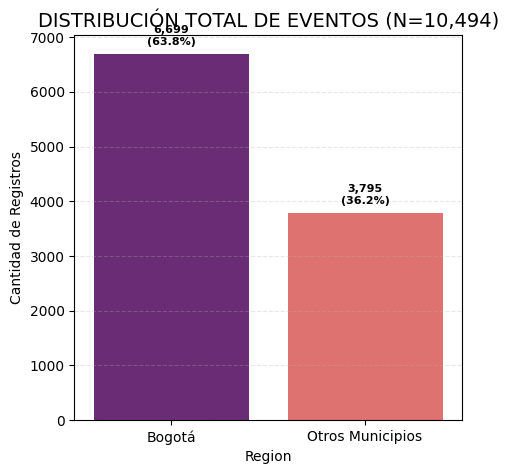

✅ Verificación de suma total: 10494


In [ ]:
# 1. Validar perdida registros (Usamos df_final_total)
# limpiar el texto
df_final_total['Municipio_Clean'] = df_final_total['Municipio'].astype(str).str.upper().str.strip()

# 2. Clasificación sin eliminar nada
def clasificar_region(muni):
    if 'BOGOT' in muni:
        return 'Bogotá'
    elif muni in ['NAN', '', 'NONE', '0']:
        return 'Sin Clasificar / Nulo'
    else:
        return 'Otros Municipios'

df_final_total['Region'] = df_final_total['Municipio_Clean'].apply(clasificar_region)

# 3. Cálculo de la tabla sobre el TOTAL
resumen_region = df_final_total['Region'].value_counts(dropna=False).reset_index()
resumen_region.columns = ['Region', 'Eventos']
resumen_region['Porcentaje'] = (resumen_region['Eventos'] / len(df_final_total)) * 100

# 4. Visualización Profesional
plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=resumen_region,
    x='Region',
    y='Eventos',
    hue='Region',
    palette='magma',
    legend=False
)

# Etiquetas con el conteo exacto y % sobre el total de 10,534
for p in ax.patches:
    height = p.get_height()
    perc = (height / len(df_final_total)) * 100
    ax.annotate(f'{int(height):,}\n({perc:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title(f'DISTRIBUCIÓN TOTAL DE EVENTOS (N={len(df_final_total):,})', fontsize=14)
plt.ylabel('Cantidad de Registros')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print(" Verificación de suma total:", resumen_region['Eventos'].sum())

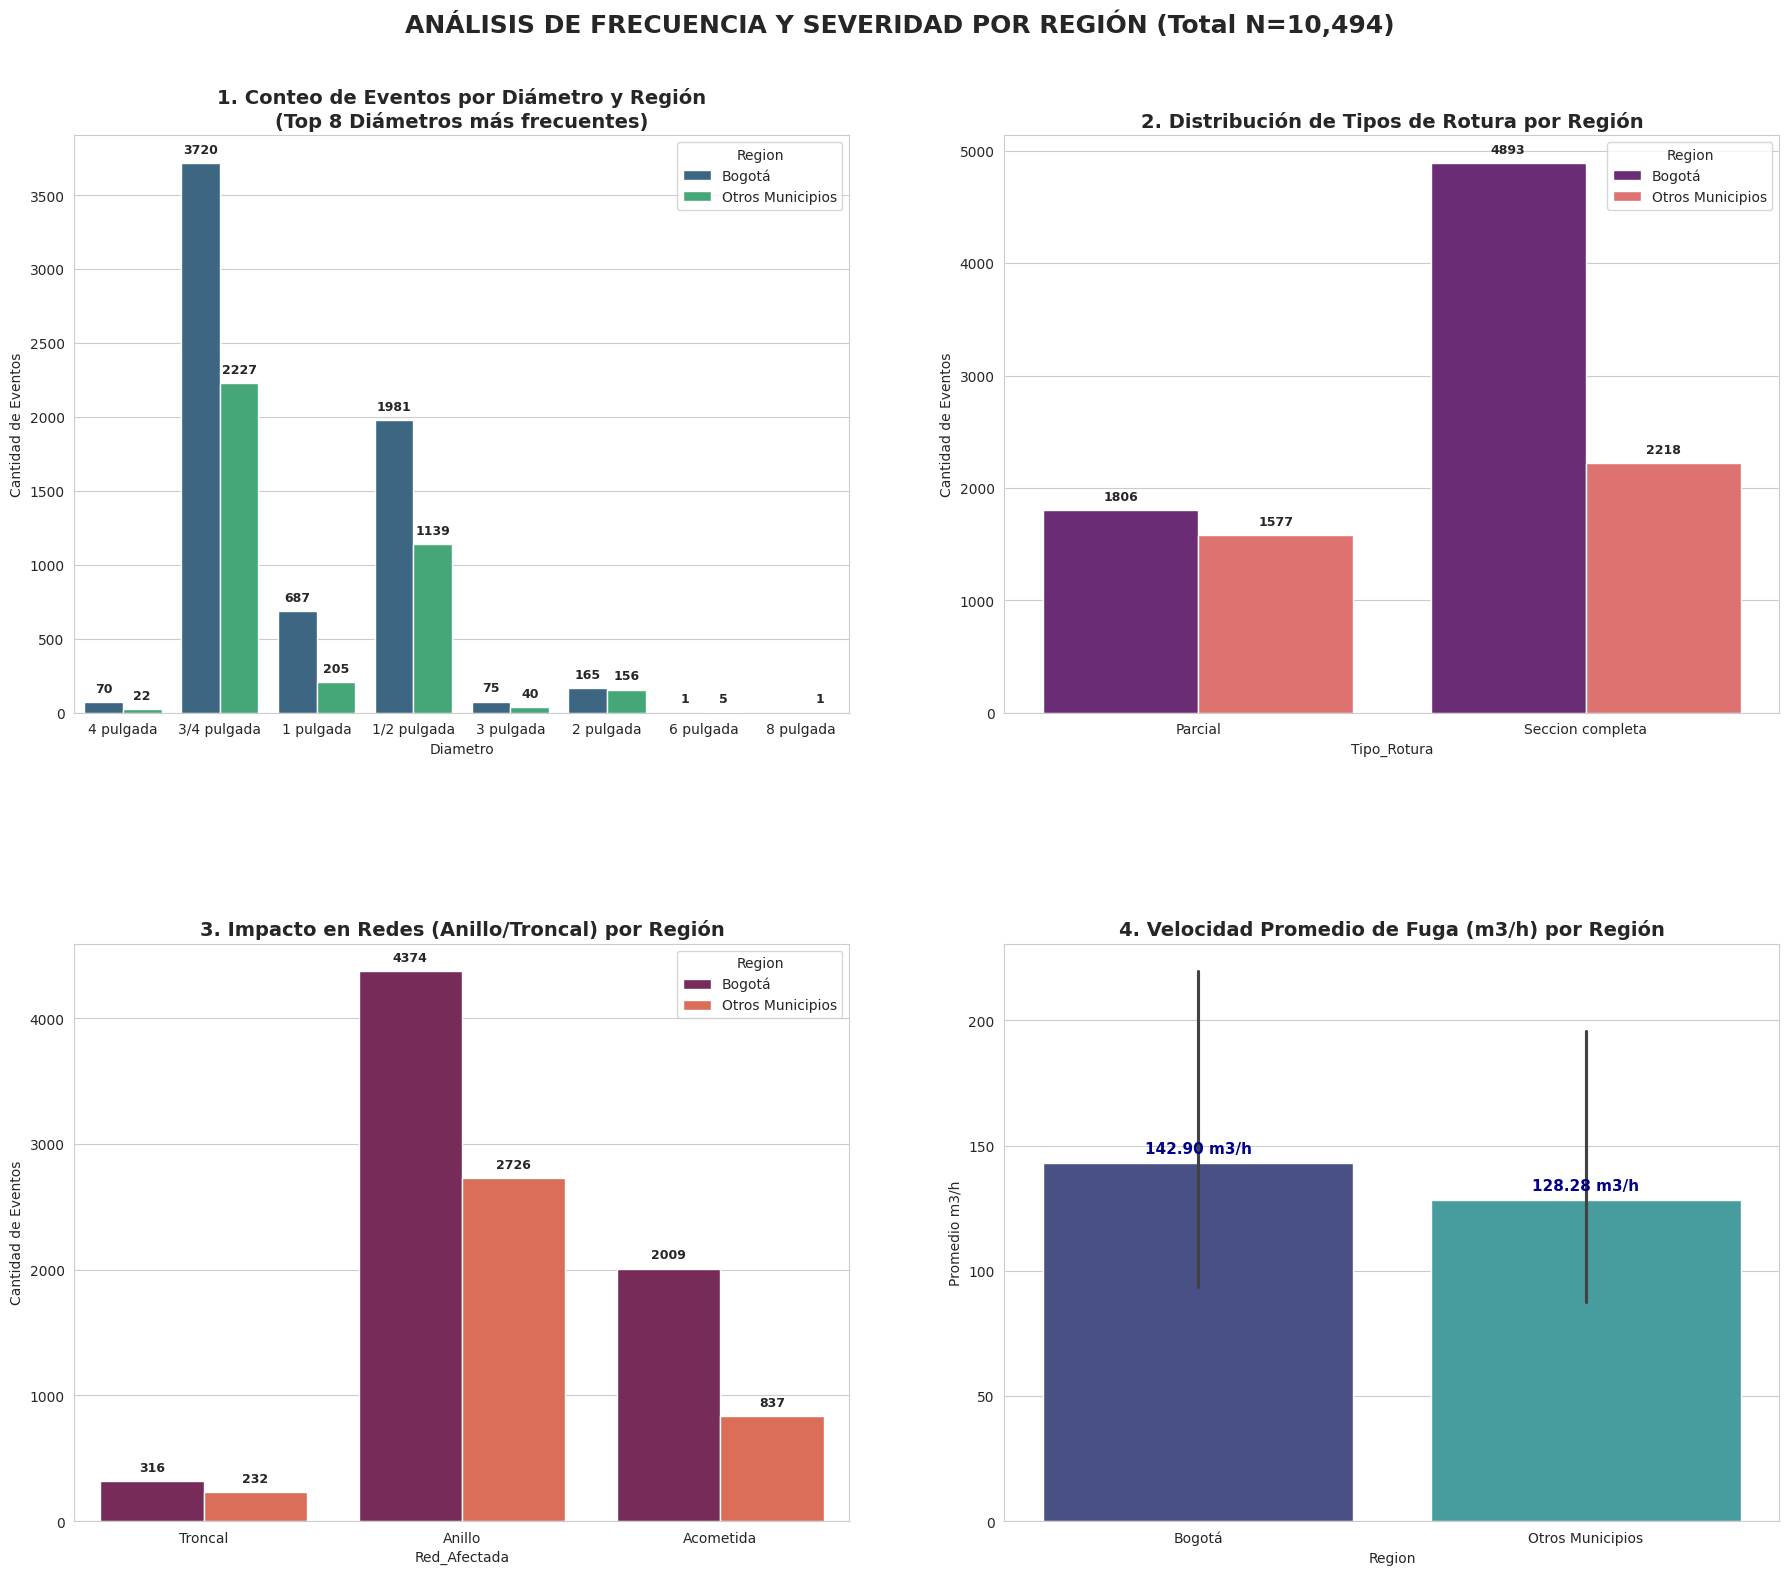


📝 RESUMEN EJECUTIVO POR REGIÓN:


,Region,Total_Eventos,Velocidad_Promedio,Duracion_Promedio
0,Bogotá,6699,142.903436,3.129547
1,Otros Municipios,3795,128.282481,3.722440


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN GENERAL ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
plt.subplots_adjust(hspace=0.4)

# Filtro rápido para que el gráfico de diámetros no sea ilegible (Top 8 diámetros más frecuentes)
top_diametros = df_final_total['Diametro'].value_counts().nlargest(8).index
df_sub = df_final_total[df_final_total['Diametro'].isin(top_diametros)]

# --- A. EVENTOS POR DIÁMETRO Y REGIÓN ---
ax1 = axes[0, 0]
sns.countplot(data=df_sub, x='Diametro', hue='Region', palette='viridis', ax=ax1)
ax1.set_title('1. Conteo de Eventos por Diámetro y Región\n(Top 8 Diámetros más frecuentes)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cantidad de Eventos')
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# --- B. TIPO DE ROTURA POR REGIÓN ---
ax2 = axes[0, 1]
sns.countplot(data=df_final_total, x='Tipo_Rotura', hue='Region', palette='magma', ax=ax2)
ax2.set_title('2. Distribución de Tipos de Rotura por Región', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cantidad de Eventos')
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# --- C. RED AFECTADA POR REGIÓN ---
ax3 = axes[1, 0]
sns.countplot(data=df_final_total, x='Red_Afectada', hue='Region', palette='rocket', ax=ax3)
ax3.set_title('3. Impacto en Redes (Anillo/Troncal) por Región', fontsize=14, fontweight='bold')
ax3.set_ylabel('Cantidad de Eventos')
for p in ax3.patches:
    if p.get_height() > 0:
        ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# --- D. VELOCIDAD PROMEDIO POR REGIÓN (Comparativa de Severidad) ---
ax4 = axes[1, 1]
sns.barplot(data=df_final_total, x='Region', y='Velocidad_Fuga_m3h', hue='Region', palette='mako', ax=ax4, legend=False)
ax4.set_title('4. Velocidad Promedio de Fuga (m3/h) por Región', fontsize=14, fontweight='bold')
ax4.set_ylabel('Promedio m3/h')
for p in ax4.patches:
    ax4.annotate(f'{p.get_height():.2f} m3/h', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkblue', xytext=(0, 5), textcoords='offset points')

plt.suptitle(f'ANÁLISIS DE FRECUENCIA Y SEVERIDAD POR REGIÓN (Total N={len(df_final_total):,})',
             fontsize=18, fontweight='bold', y=0.95)

plt.show()

# --- TABLA DE APOYO PARA EL INFORME ---
print("\n RESUMEN EJECUTIVO POR REGIÓN:")
tabla_resumen = df_final_total.groupby('Region').agg(
    Total_Eventos=('ID_Original', 'count'),
    Velocidad_Promedio=('Velocidad_Fuga_m3h', 'mean'),
    Duracion_Promedio=('Duracion_Fuga_H', 'mean')
).reset_index()
display(tabla_resumen)

## 3.2 Distribución de Severidad

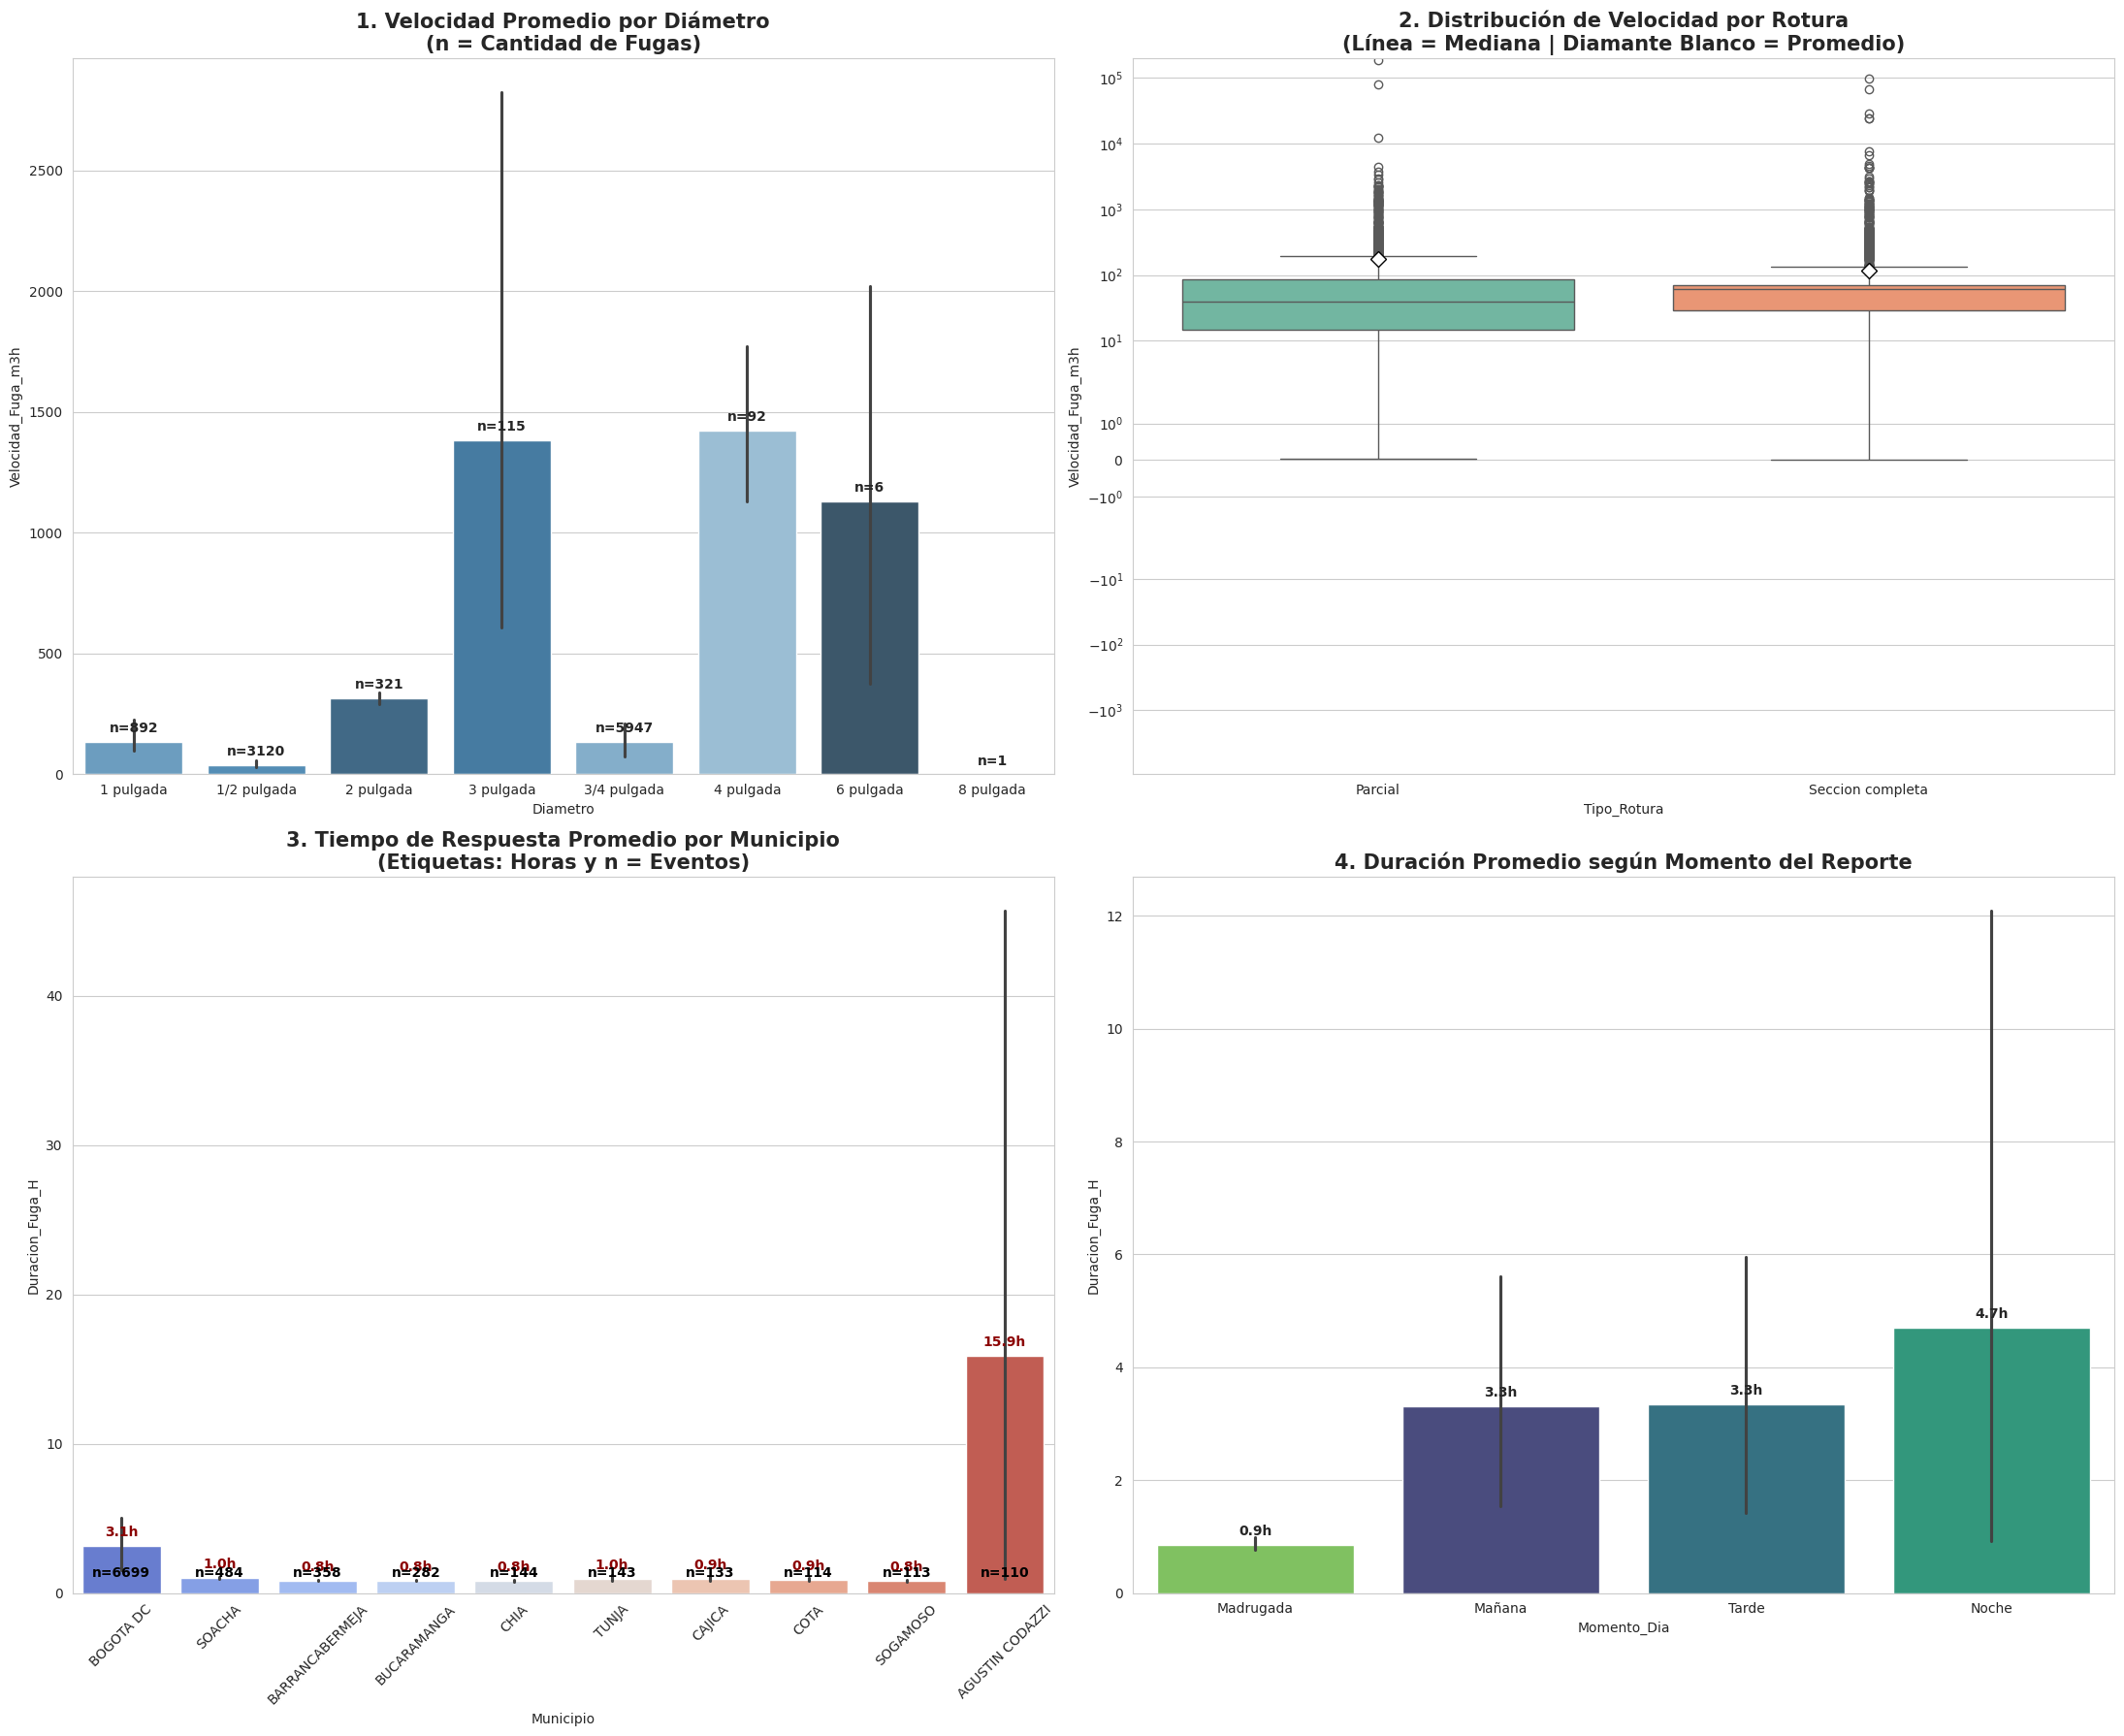

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos datos limpios
df_viz = df_final_total.copy()

# --- CONFIGURACIÓN DE GRÁFICOS ---
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
sns.set_style("whitegrid")

# --- A. DIÁMETRO VS VELOCIDAD (Barplot) ---
ax1 = axes[0, 0]
order_diam = sorted(df_viz['Diametro'].dropna().unique(), key=lambda x: str(x))
sns.barplot(ax=ax1, data=df_viz, x='Diametro', y='Velocidad_Fuga_m3h', palette='Blues_d', order=order_diam, hue='Diametro', legend=False)
ax1.set_title('1. Velocidad Promedio por Diámetro\n(n = Cantidad de Fugas)', fontsize=15, fontweight='bold')

for p in ax1.patches:
    # Obtenemos el conteo para el diámetro actual
    current_diam = order_diam[int(p.get_x() + p.get_width()/2)]
    n_eventos = df_viz[df_viz['Diametro'] == current_diam].shape[0]
    ax1.annotate(f'n={n_eventos}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# --- B. TIPO DE ROTURA VS VELOCIDAD (Boxplot con Media Marcada) ---
ax2 = axes[0, 1]
# showmeans=True dibuja el promedio. meanprops le da formato.
sns.boxplot(ax=ax2, data=df_viz, x='Tipo_Rotura', y='Velocidad_Fuga_m3h', palette='Set2', hue='Tipo_Rotura', legend=False,
            showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
ax2.set_yscale('symlog')
ax2.set_title('2. Distribución de Velocidad por Rotura\n(Línea = Mediana | Diamante Blanco = Promedio)', fontsize=15, fontweight='bold')

# --- C. MUNICIPIOS: TIEMPO VS EVENTOS (Barplot Mixto) ---
ax3 = axes[1, 0]
top_muni = df_viz['Municipio'].value_counts().nlargest(10).index
df_muni = df_viz[df_viz['Municipio'].isin(top_muni)]
sns.barplot(ax=ax3, data=df_muni, x='Municipio', y='Duracion_Fuga_H', palette='coolwarm', hue='Municipio', legend=False)
ax3.set_title('3. Tiempo de Respuesta Promedio por Municipio\n(Etiquetas: Horas y n = Eventos)', fontsize=15, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

for p in ax3.patches:
    muni_name = top_muni[int(p.get_x() + p.get_width()/2)]
    n_muni = df_viz[df_viz['Municipio'] == muni_name].shape[0]
    # Etiqueta de Horas (Arriba)
    ax3.annotate(f'{p.get_height():.1f}h', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold', color='darkred')
    # Etiqueta de Eventos (Abajo, cerca de la base o en medio)
    ax3.annotate(f'n={n_muni}', (p.get_x() + p.get_width() / 2., 0),
                 ha='center', va='bottom', xytext=(0, 10), textcoords='offset points', fontsize=10, color='black', fontweight='bold')

# --- D. MOMENTO DEL DÍA VS DURACIÓN (Barplot) ---
ax4 = axes[1, 1]
sns.barplot(ax=ax4, data=df_viz, x='Momento_Dia', y='Duracion_Fuga_H', order=["Madrugada", "Mañana", "Tarde", "Noche"], palette='viridis', hue='Momento_Dia', legend=False)
ax4.set_title('4. Duración Promedio según Momento del Reporte', fontsize=15, fontweight='bold')

for p in ax4.patches:
    ax4.annotate(f'{p.get_height():.1f}h', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. DataFrame Bogotá
df_bogota = df_final_total[df_final_total['Region'] == 'Bogotá'].copy()

# 2. DataFrame Otros Municipios
df_municipios = df_final_total[df_final_total['Region'] == 'Otros Municipios'].copy()

print(f"📊 Segmentación completada:")
print(f"🏙️ Bogotá: {len(df_bogota):,} registros")
print(f"🏘️ Municipios: {len(df_municipios):,} registros")

# Verificación de integridad: ¿Sumamos los 10,534 originales? (Menos nulos en región)
total_segmentado = len(df_bogota) + len(df_municipios)
print(f" Total segmentado: {total_segmentado:,}")

📊 Segmentación completada:
🏙️ Bogotá: 6,699 registros
🏘️ Municipios: 3,795 registros
✅ Total segmentado: 10,494


# Cap 4: Análisis de Outliers por Región

In [ ]:
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return limite_superior

# 1. Calculamos límites específicos por región para ser justos con la data
regiones = ['Bogotá', 'Otros Municipios']
df_final_total['Outlier_Duracion'] = False
df_final_total['Outlier_Velocidad'] = False

for reg in regiones:
    mask = df_final_total['Region'] == reg
    df_reg = df_final_total[mask]

    lim_dur = detectar_outliers_iqr(df_reg, 'Duracion_Fuga_H')
    lim_vel = detectar_outliers_iqr(df_reg, 'Velocidad_Fuga_m3h')

    df_final_total.loc[mask, 'Outlier_Duracion'] = df_final_total.loc[mask, 'Duracion_Fuga_H'] > lim_dur
    df_final_total.loc[mask, 'Outlier_Velocidad'] = df_final_total.loc[mask, 'Velocidad_Fuga_m3h'] > lim_vel

# 2. Categorización de registros
def categorizar_outlier(row):
    if row['Outlier_Duracion'] and row['Outlier_Velocidad']:
        return 'Outlier Total (Ambos)'
    elif row['Outlier_Duracion']:
        return 'Outlier de Duración'
    elif row['Outlier_Velocidad']:
        return 'Outlier de Velocidad'
    else:
        return 'Registro Estándar'

df_final_total['Categoria_Outlier'] = df_final_total.apply(categorizar_outlier, axis=1)

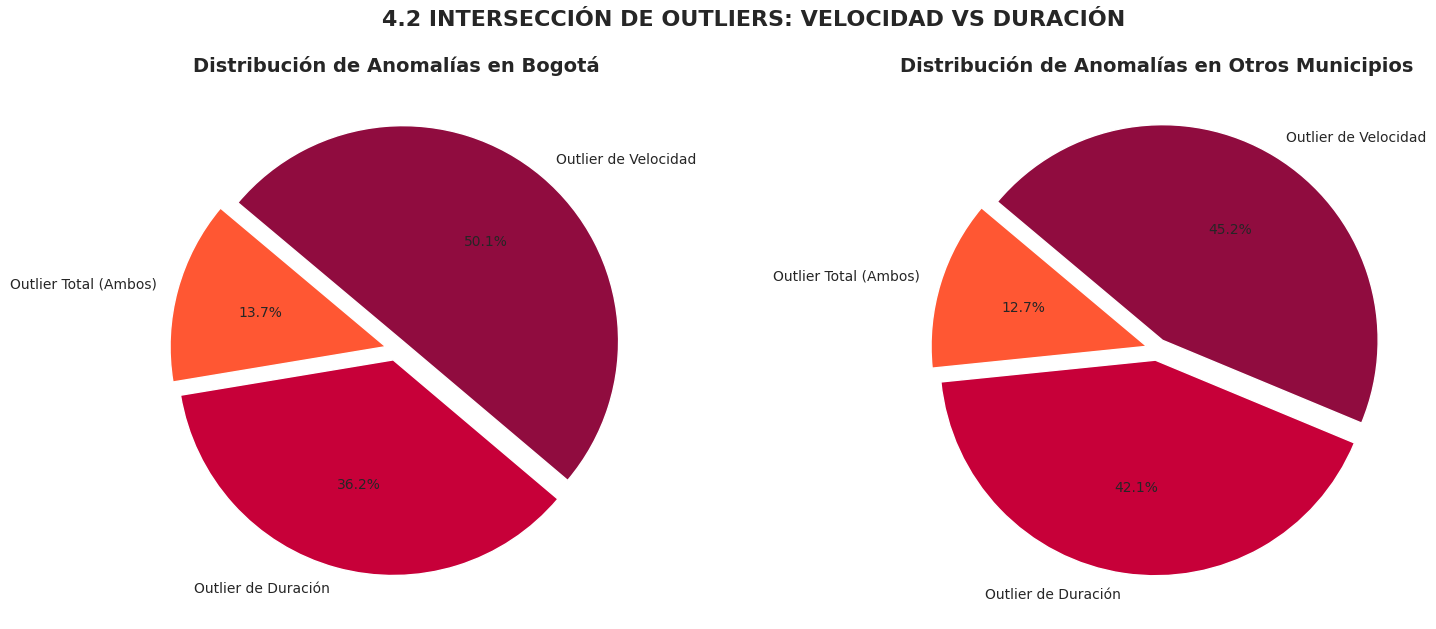

📝 RESUMEN CUANTITATIVO DE OUTLIERS:


Categoria_Outlier,Outlier Total (Ambos),Outlier de Duración,Outlier de Velocidad,Registro Estándar
Region,,,,
Bogotá,124,327,452,5796
Otros Municipios,71,235,252,3237


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear tabla cruzada para el gráfico
resumen_outliers = df_final_total.groupby(['Region', 'Categoria_Outlier']).size().unstack(fill_value=0)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

for i, reg in enumerate(regiones):
    data_plot = resumen_outliers.loc[reg]
    # No graficamos el 'Registro Estándar' para enfocarnos en las anomalías
    data_anomalias = data_plot.drop('Registro Estándar', errors='ignore')

    ax[i].pie(data_anomalias, labels=data_anomalias.index, autopct='%1.1f%%',
              colors=['#FF5733', '#C70039', '#900C3F'], startangle=140, explode=[0.05]*len(data_anomalias))
    ax[i].set_title(f'Distribución de Anomalías en {reg}', fontsize=14, fontweight='bold')

plt.suptitle('4.2 INTERSECCIÓN DE OUTLIERS: VELOCIDAD VS DURACIÓN', fontsize=16, fontweight='bold')
plt.show()

print(" RESUMEN CUANTITATIVO DE OUTLIERS:")
display(resumen_outliers)

## 4.1 Matriz Correlación por Segmento Regional

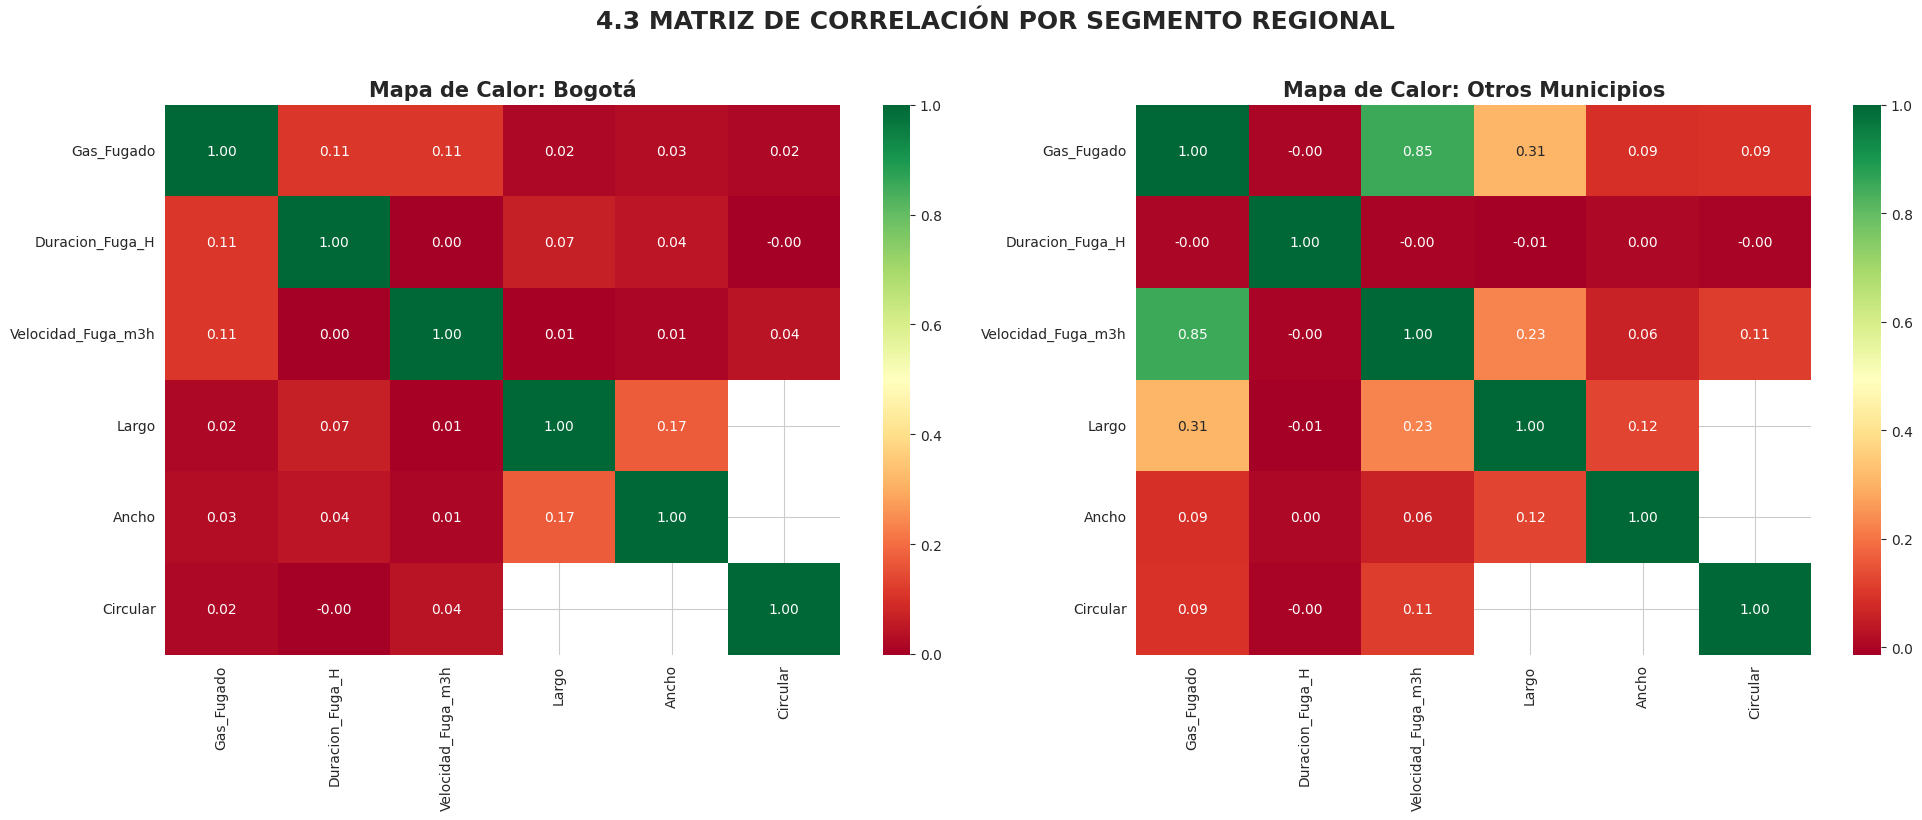

In [ ]:
# Seleccionamos variables numéricas clave
cols_corr = ['Gas_Fugado', 'Duracion_Fuga_H', 'Velocidad_Fuga_m3h', 'Largo', 'Ancho', 'Circular']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, reg in enumerate(regiones):
    df_corr = df_final_total[df_final_total['Region'] == reg][cols_corr].corr()

    sns.heatmap(df_corr, annot=True, cmap='RdYlGn', fmt=".2f", ax=axes[i], cbar=True)
    axes[i].set_title(f'Mapa de Calor: {reg}', fontsize=15, fontweight='bold')

plt.suptitle('4.3 MATRIZ DE CORRELACIÓN POR SEGMENTO REGIONAL', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cap 5: Investigación de Correlaciones y Encoding

## 5.1 Preparación: One-Hot Encoding (Sin Drop)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos las variables para el análisis de correlación expandido
vars_categoricas = ['Tipo_Rotura', 'Diametro', 'Red_Afectada', 'Momento_Dia']
var_objetivo = ['Velocidad_Fuga_m3h', 'Gas_Fugado', 'Duracion_Fuga_H']

# 2. Aplicamos One-Hot Encoding sin eliminar la primera columna (get_dummies)
# Lo hacemos por región como acordamos
def generar_matriz_expandida(df_segmento):
    df_cat = pd.get_dummies(df_segmento[vars_categoricas], prefix=vars_categoricas)
    # Unimos con las numéricas
    df_completo = pd.concat([df_cat, df_segmento[var_objetivo]], axis=1)
    return df_completo

df_corr_bogota = generar_matriz_expandida(df_bogota)
df_corr_muni = generar_matriz_expandida(df_municipios)

##5.2 Matrix Binaria (One- Hot Encoding)

<>:9: SyntaxWarning: invalid escape sequence '\B'
<>:9: SyntaxWarning: invalid escape sequence '\B'
/tmp/ipython-input-3308570560.py:9: SyntaxWarning: invalid escape sequence '\B'
  plt.title("Muestra de Matriz Binaria (One-Hot Encoding)\Bogotá", fontsize=14)


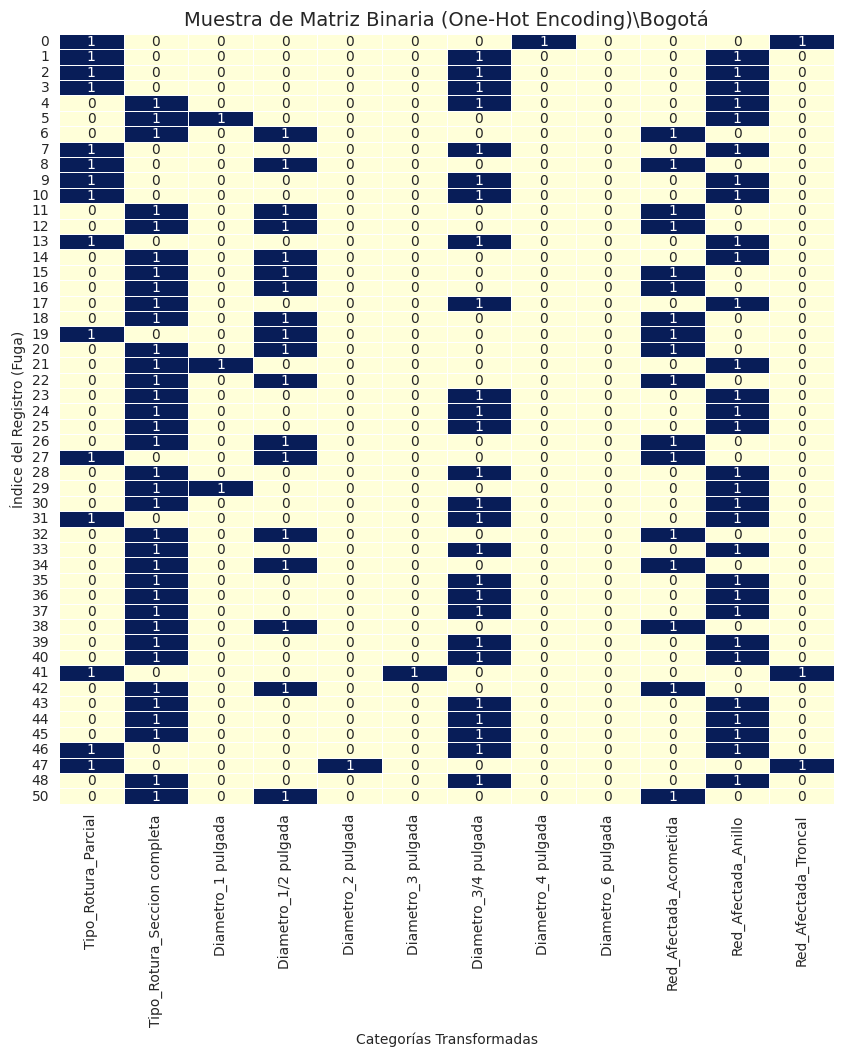

In [ ]:
# Vamos a ver los primeros 15 registros de la matriz de Bogotá
# para entender cómo se distribuyen los 1s y 0s

# Seleccionamos solo las primeras columnas de categorías para que quepan en pantalla
muestra_binaria = df_corr_bogota.iloc[:50, :12]

plt.figure(figsize=(10, 10))
sns.heatmap(muestra_binaria, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title("Muestra de Matriz Binaria (One-Hot Encoding)\Bogotá", fontsize=14)
plt.xlabel("Categorías Transformadas")
plt.ylabel("Índice del Registro (Fuga)")
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipython-input-4171990275.py:9: SyntaxWarning: invalid escape sequence '\O'
  plt.title("Muestra de Matriz Binaria (One-Hot Encoding)\Otros Municipios", fontsize=14)


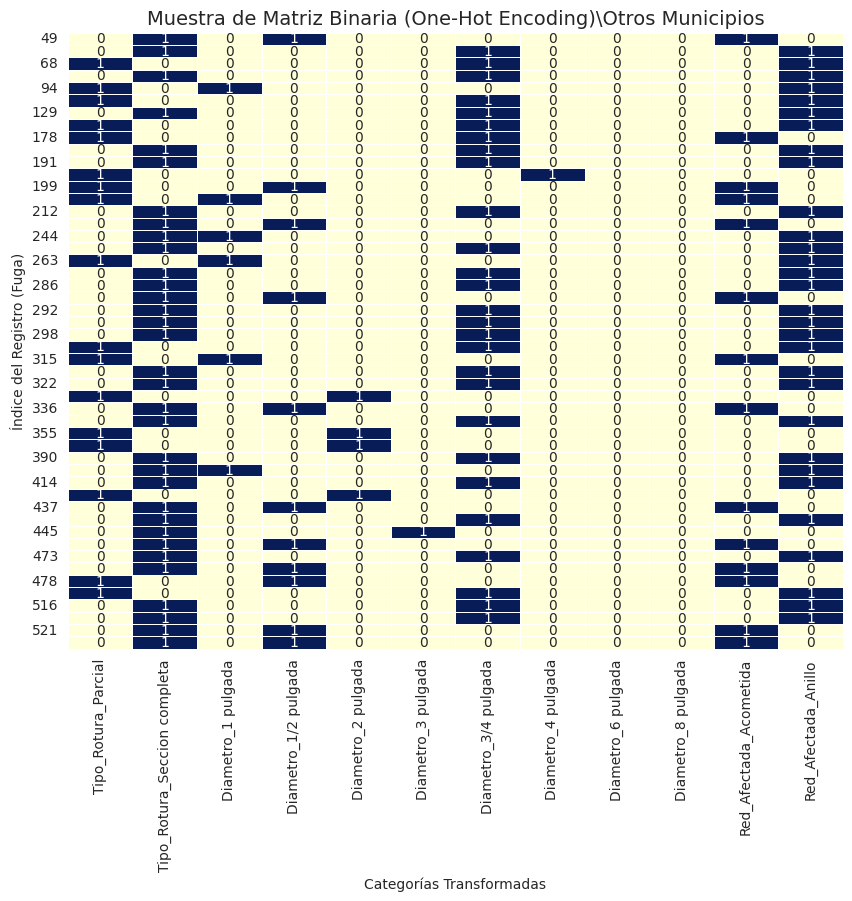

In [ ]:
# Vamos a ver los primeros 15 registros de la matriz de Bogotá
# para entender cómo se distribuyen los 1s y 0s

# Seleccionamos solo las primeras columnas de categorías para que quepan en pantalla
muestra_binaria = df_corr_muni.iloc[:50, :12]

plt.figure(figsize=(10,8))
sns.heatmap(muestra_binaria, annot=True, cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title("Muestra de Matriz Binaria (One-Hot Encoding)\Otros Municipios", fontsize=14)
plt.xlabel("Categorías Transformadas")
plt.ylabel("Índice del Registro (Fuga)")
plt.show()

##5.3 Análisis de Correlación: Categorías vs. Numéricas

🏙️ ANÁLISIS BOGOTÁ:


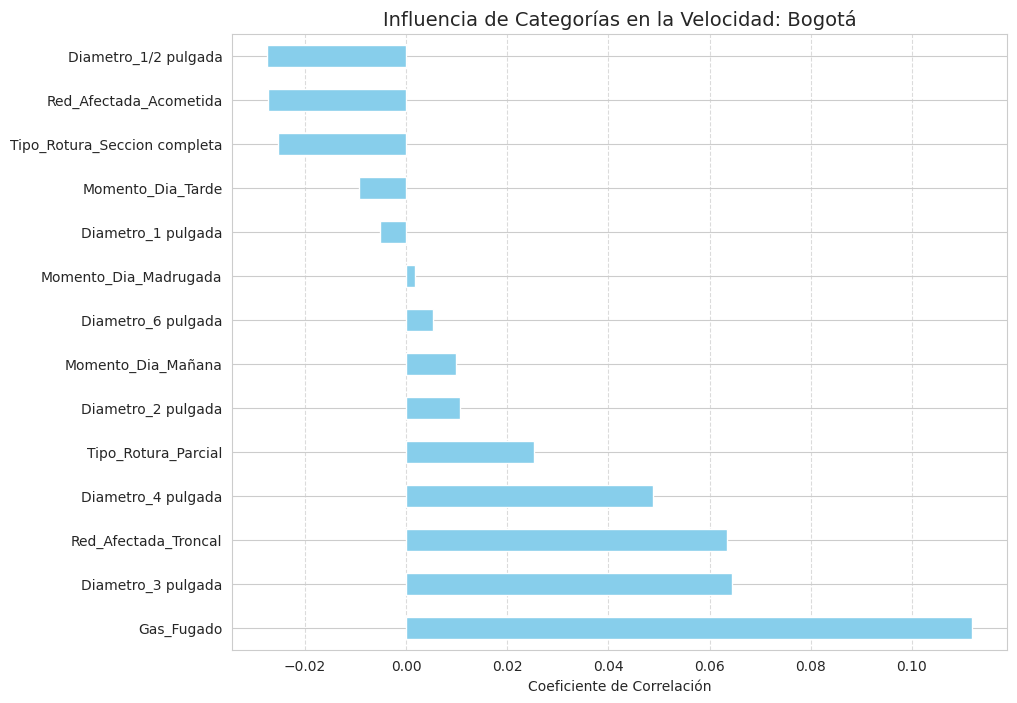


🏘️ ANÁLISIS MUNICIPIOS:


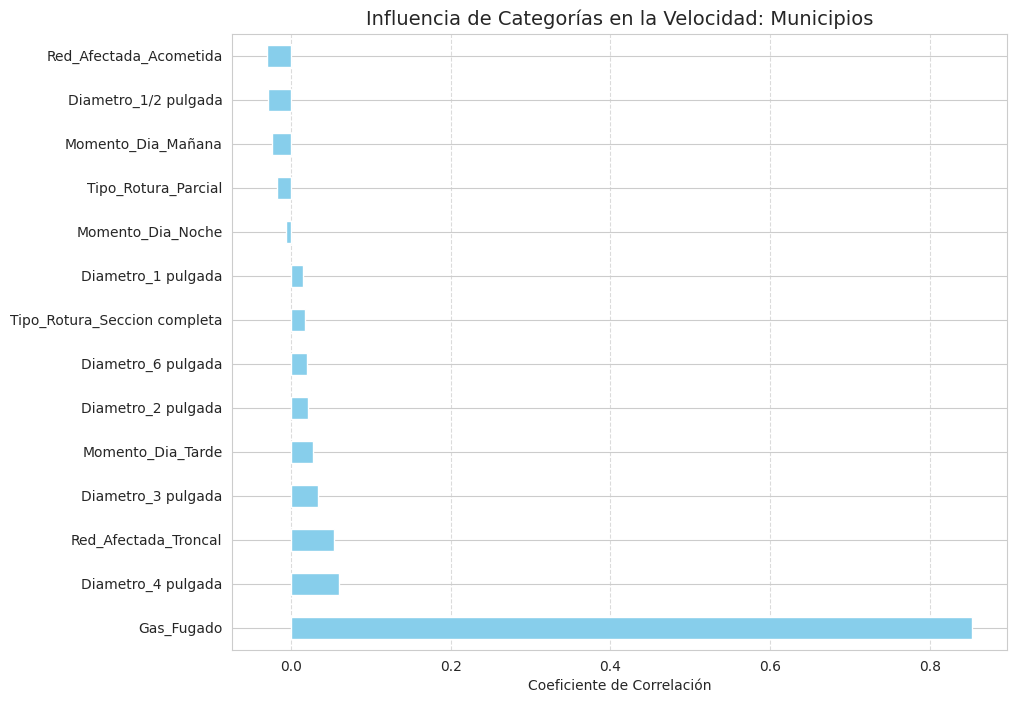

In [ ]:
def analizar_pesos_correlacion(df_encoding, titulo):
    # Calculamos la correlación de todas las nuevas columnas contra la Velocidad
    corr_target = df_encoding.corr()['Velocidad_Fuga_m3h'].sort_values(ascending=False)

    # Filtramos para ver las 15 más influyentes (positivas y negativas)
    top_corr = pd.concat([corr_target.head(10), corr_target.tail(5)])

    plt.figure(figsize=(10, 8))
    top_corr.drop('Velocidad_Fuga_m3h').plot(kind='barh', color='skyblue')
    plt.title(f'Influencia de Categorías en la Velocidad: {titulo}', fontsize=14)
    plt.xlabel('Coeficiente de Correlación')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return corr_target

print("🏙️ ANÁLISIS BOGOTÁ:")
pesos_bogota = analizar_pesos_correlacion(df_corr_bogota, "Bogotá")

print("\n🏘️ ANÁLISIS MUNICIPIOS:")
pesos_muni = analizar_pesos_correlacion(df_corr_muni, "Municipios")

## 5.4 Verificación de Colinealidad (Relación entre categorías)

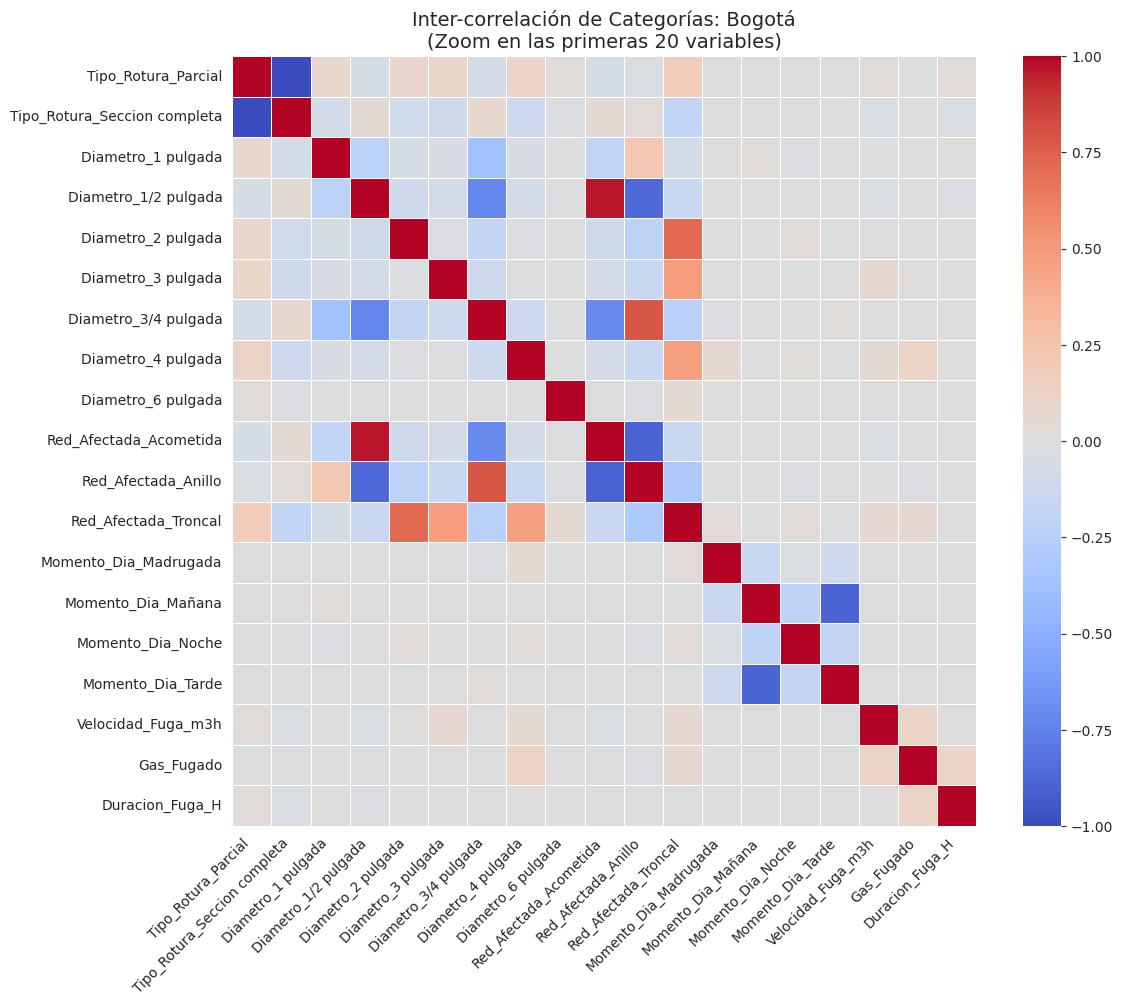

In [ ]:
def mapa_calor_etiquetado(df_encoding, region_name):
    # Tomamos solo las 20 columnas más importantes para que sea legible
    cols_dummies = [c for c in df_encoding.columns if '_' in c][:20]
    matriz_cat = df_encoding[cols_dummies].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(matriz_cat, cmap='coolwarm', annot=False, fmt=".1f", linewidths=.5)
    plt.title(f'Inter-correlación de Categorías: {region_name}\n(Zoom en las primeras 20 variables)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# Pruébalo con Bogotá
mapa_calor_etiquetado(df_corr_bogota, "Bogotá")

5.4 Análisis de Correlación: Influencia sobre el Gas Fugado

🏙️ IMPACTO DE GAS EN BOGOTÁ:


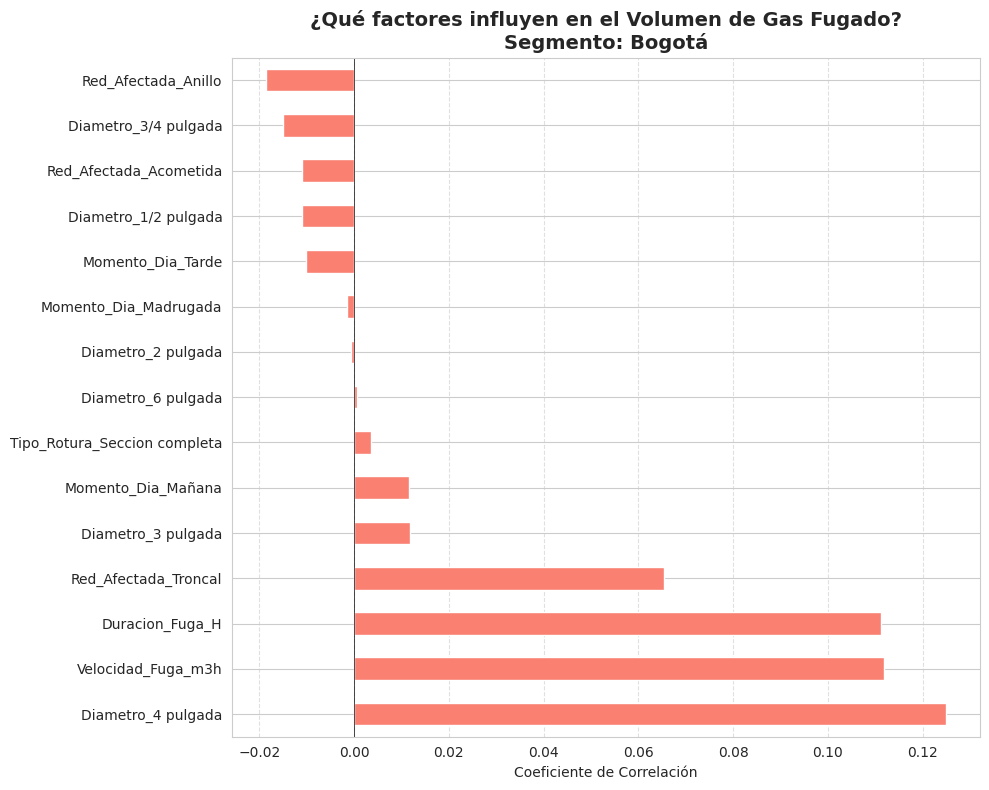


🏘️ IMPACTO DE GAS EN MUNICIPIOS:


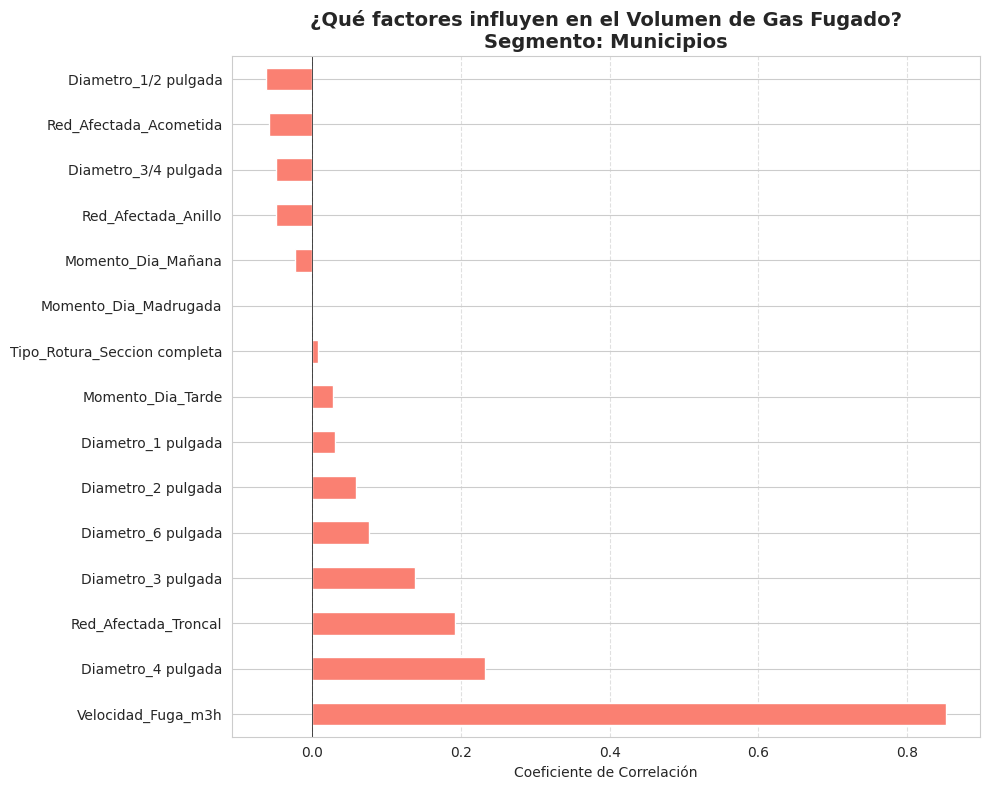

In [ ]:
def analizar_correlacion_gas(df_encoding, titulo):
    # Calculamos la correlación de todas las categorías contra Gas_Fugado
    corr_gas = df_encoding.corr()['Gas_Fugado'].sort_values(ascending=False)

    # Seleccionamos el Top 10 de influencias positivas (lo que más aumenta el gas)
    # y el Top 5 de influencias negativas (lo que menos gas genera)
    top_impacto = pd.concat([corr_gas.head(11), corr_gas.tail(5)])

    # Graficamos
    plt.figure(figsize=(10, 8))
    # Eliminamos la propia variable 'Gas_Fugado' de la gráfica para que no opaque al resto
    top_impacto.drop('Gas_Fugado', errors='ignore').plot(kind='barh', color='salmon')

    plt.title(f'¿Qué factores influyen en el Volumen de Gas Fugado?\nSegmento: {titulo}', fontsize=14, fontweight='bold')
    plt.xlabel('Coeficiente de Correlación')
    plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return corr_gas

print(" IMPACTO DE GAS EN BOGOTÁ:")
pesos_gas_bogota = analizar_correlacion_gas(df_corr_bogota, "Bogotá")

print("\n IMPACTO DE GAS EN MUNICIPIOS:")
pesos_gas_muni = analizar_correlacion_gas(df_corr_muni, "Municipios")

In [ ]:
print(" Auditoría de columna Duración en Municipios:")
print(f"Cantidad de registros: {len(df_municipios)}")
print(f"Valores nulos en Duración: {df_municipios['Duracion_Fuga_H'].isna().sum()}")
print(f"Promedio de Duración: {df_municipios['Duracion_Fuga_H'].mean():.2f} h")

📊 Auditoría de columna Duración en Municipios:
Cantidad de registros: 3795
Valores nulos en Duración: 0
Promedio de Duración: 3.72 h


In [ ]:
print(" Auditoría de columna Duración en Bogota:")
print(f"Cantidad de registros: {len(df_bogota)}")
print(f"Valores nulos en Duración: {df_bogota['Duracion_Fuga_H'].isna().sum()}")
print(f"Promedio de Duración: {df_bogota['Duracion_Fuga_H'].mean():.2f} h")

📊 Auditoría de columna Duración en Bogota:
Cantidad de registros: 6699
Valores nulos en Duración: 0
Promedio de Duración: 3.13 h


In [ ]:
# Calculamos la correlación específica para Municipios
corr_especifica_muni = df_corr_muni.corr()

# Buscamos cuánto pesa la Duración sobre el Gas y la Velocidad
relacion_duracion_gas = corr_especifica_muni.loc['Duracion_Fuga_H', 'Gas_Fugado']
relacion_duracion_vel = corr_especifica_muni.loc['Duracion_Fuga_H', 'Velocidad_Fuga_m3h']

print(f" Relación Duración -> Gas en Municipios: {relacion_duracion_gas:.4f}")
print(f" Relación Duración -> Velocidad en Municipios: {relacion_duracion_vel:.4f}")

🔗 Relación Duración -> Gas en Municipios: -0.0010
🔗 Relación Duración -> Velocidad en Municipios: -0.0027


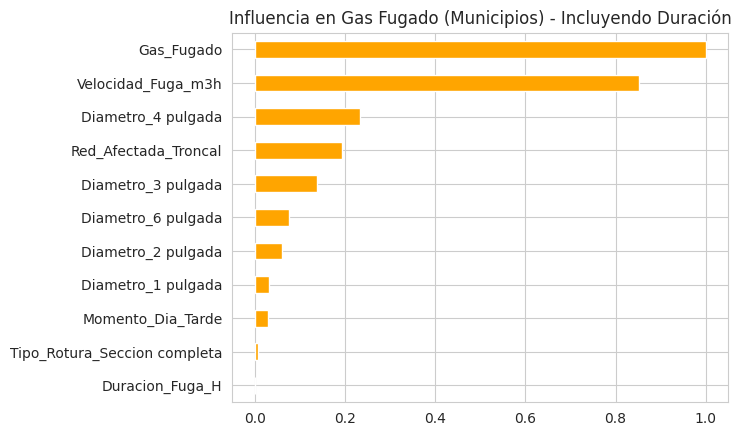

In [ ]:
def grafico_forzado_muni(df_encoding):
    corr = df_encoding.corr()['Gas_Fugado'].sort_values(ascending=False)

    # Creamos un Top 10 pero nos aseguramos de incluir la Duración
    top_plot = corr.head(10).copy()
    if 'Duracion_Fuga_H' not in top_plot.index:
        top_plot['Duracion_Fuga_H'] = corr['Duracion_Fuga_H']

    top_plot.sort_values().plot(kind='barh', color='orange')
    plt.title("Influencia en Gas Fugado (Municipios) - Incluyendo Duración")
    plt.show()

grafico_forzado_muni(df_corr_muni)

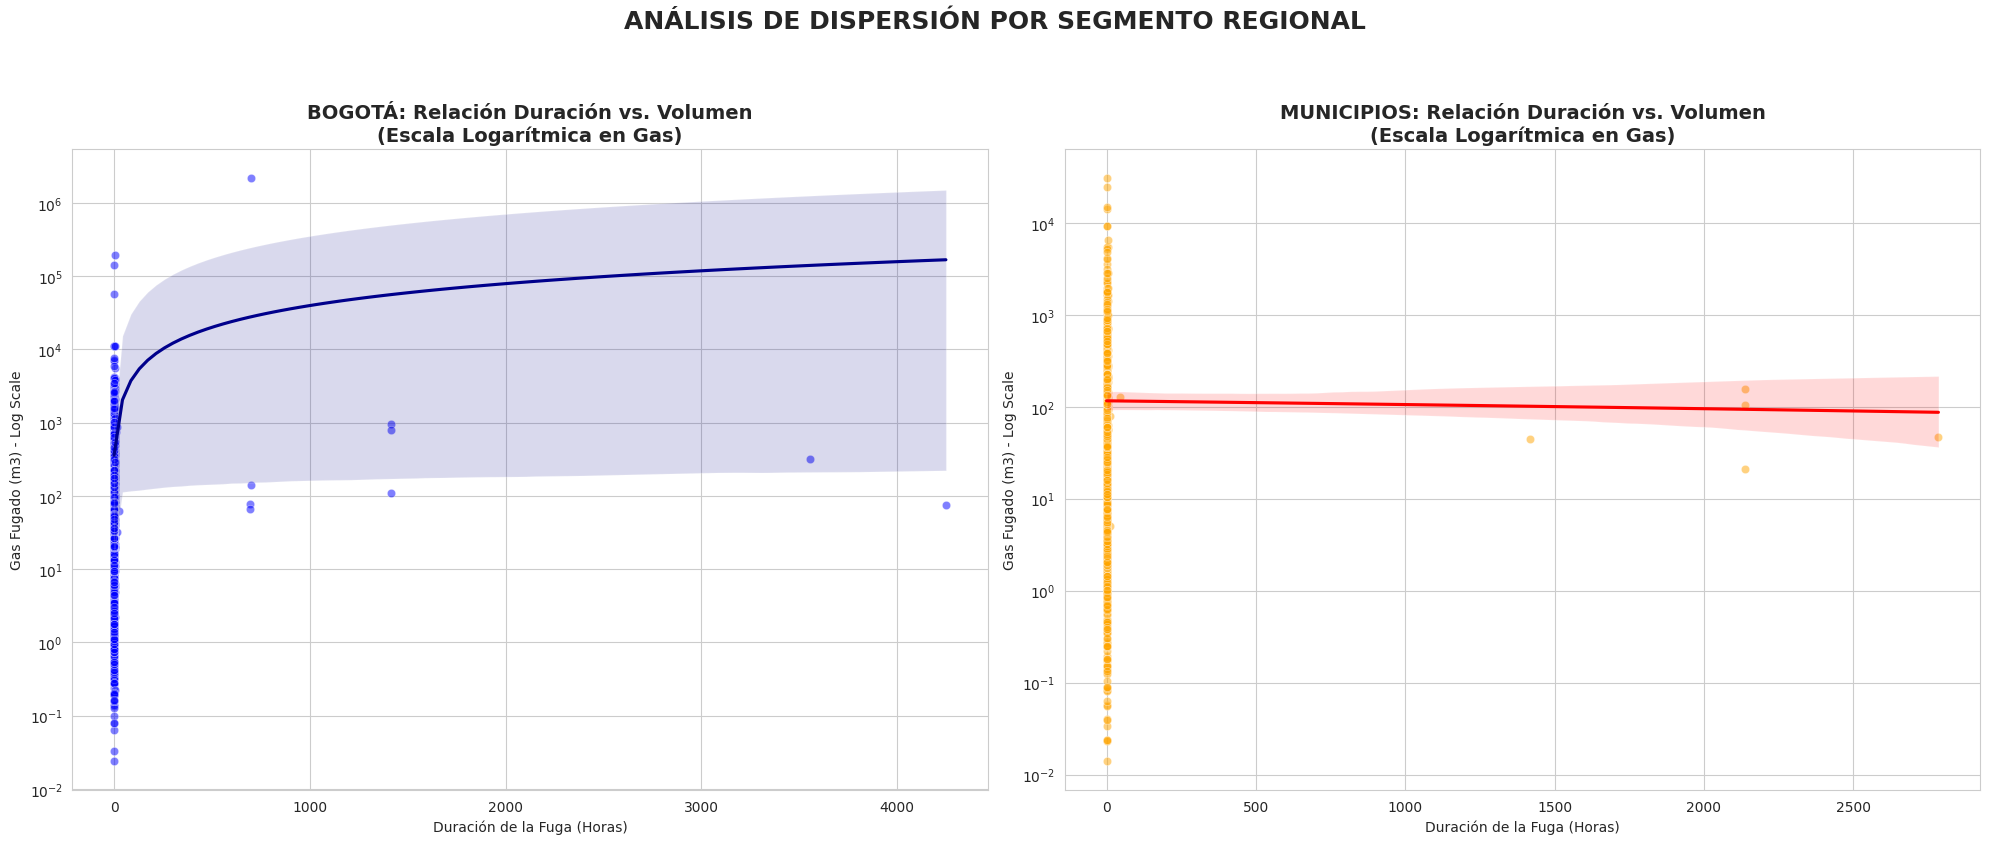

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos la figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. SCATTER PLOT PARA BOGOTÁ
sns.scatterplot(
    data=df_bogota,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.5,
    color='blue',
    ax=axes[0]
)
# Añadimos una línea de tendencia para ver la dirección
sns.regplot(data=df_bogota, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='darkblue', ax=axes[0])
axes[0].set_yscale('log') # Escala logarítmica para ver mejor la distribución
axes[0].set_title(f'BOGOTÁ: Relación Duración vs. Volumen\n(Escala Logarítmica en Gas)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duración de la Fuga (Horas)')
axes[0].set_ylabel('Gas Fugado (m3) - Log Scale')

# 2. SCATTER PLOT PARA MUNICIPIOS
sns.scatterplot(
    data=df_municipios,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.5,
    color='orange',
    ax=axes[1]
)
# Añadimos la línea de tendencia (que probablemente saldrá casi plana)
sns.regplot(data=df_municipios, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='red', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title(f'MUNICIPIOS: Relación Duración vs. Volumen\n(Escala Logarítmica en Gas)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duración de la Fuga (Horas)')
axes[1].set_ylabel('Gas Fugado (m3) - Log Scale')

plt.suptitle('ANÁLISIS DE DISPERSIÓN POR SEGMENTO REGIONAL', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

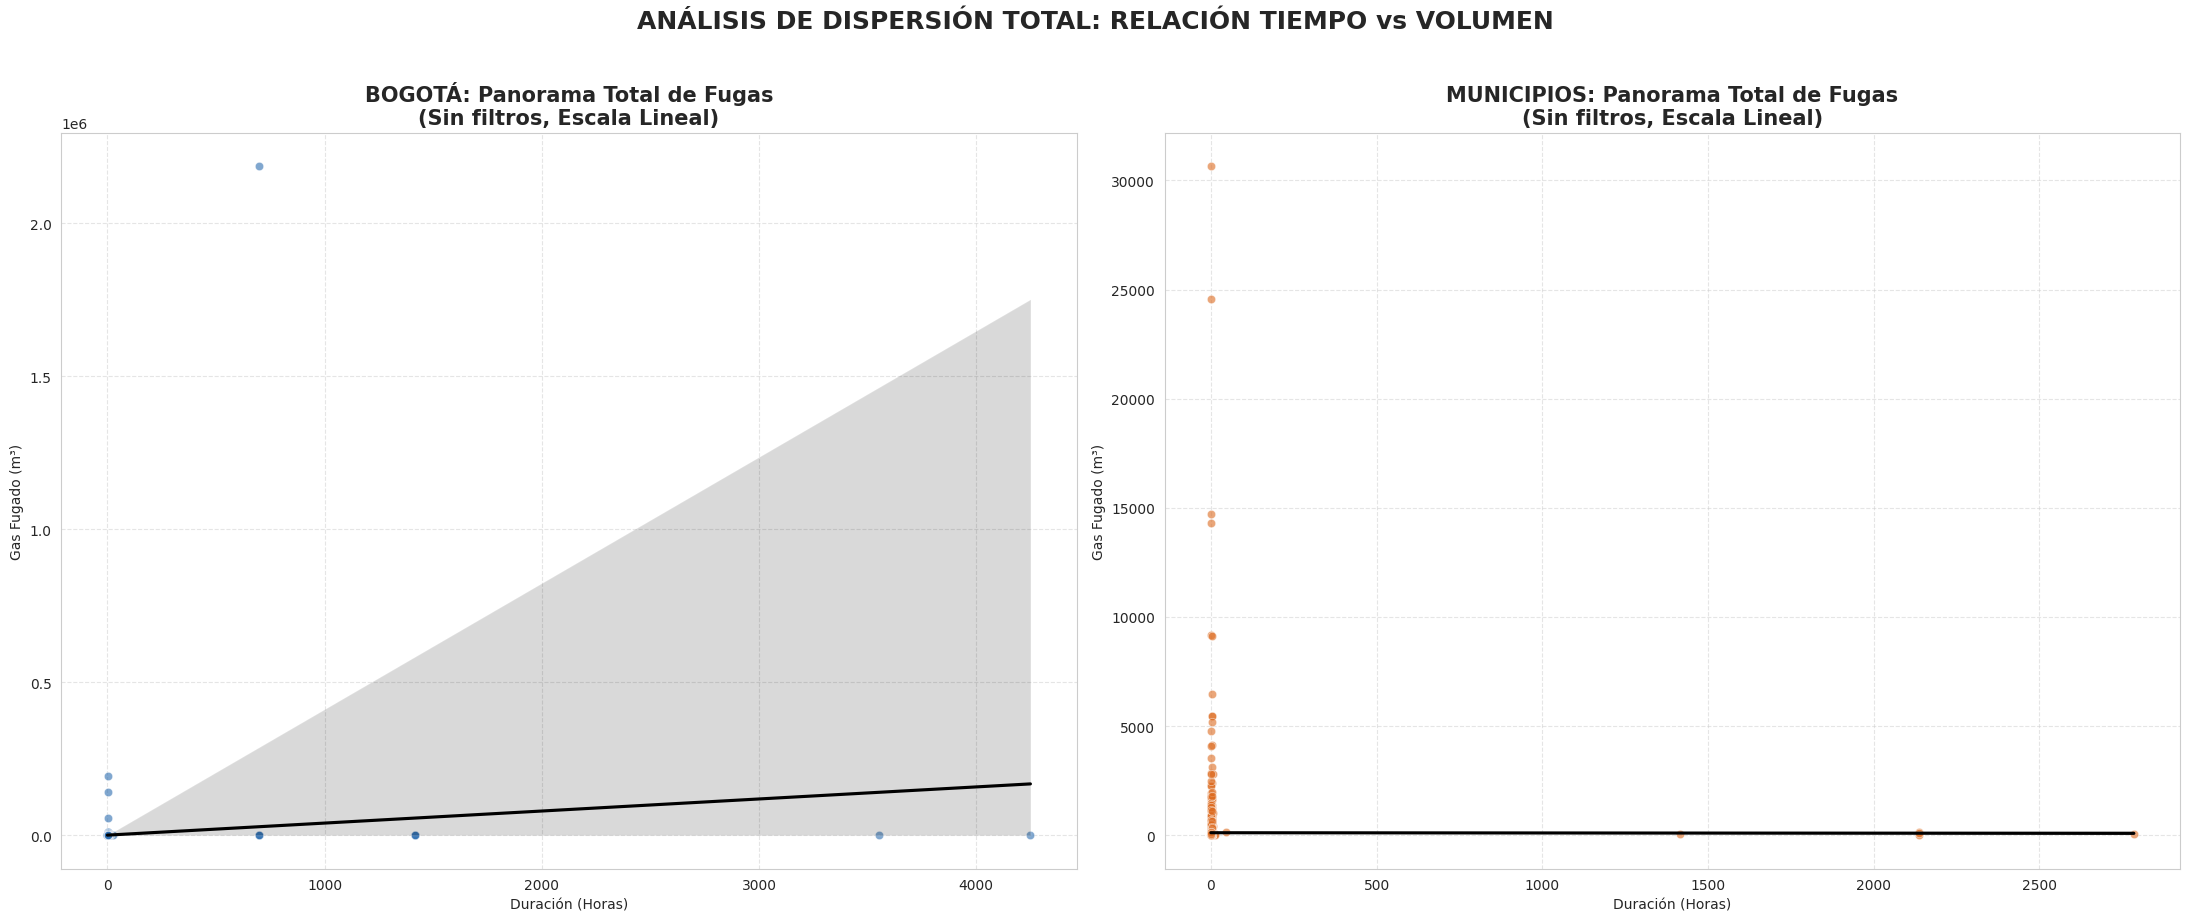

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo para los dos panoramas
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# 1. PANORAMA TOTAL BOGOTÁ (Escala Lineal Real)
sns.scatterplot(
    data=df_bogota,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.6,
    color='#2b6cb0', # Azul corporativo
    ax=axes[0]
)
# Línea de tendencia lineal
sns.regplot(data=df_bogota, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='black', ax=axes[0])
axes[0].set_title('BOGOTÁ: Panorama Total de Fugas\n(Sin filtros, Escala Lineal)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Gas Fugado (m³)')
axes[0].set_xlabel('Duración (Horas)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. PANORAMA TOTAL MUNICIPIOS (Escala Lineal Real)
sns.scatterplot(
    data=df_municipios,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.6,
    color='#dd6b20', # Naranja municipios
    ax=axes[1]
)
# Línea de tendencia lineal
sns.regplot(data=df_municipios, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='black', ax=axes[1])
axes[1].set_title('MUNICIPIOS: Panorama Total de Fugas\n(Sin filtros, Escala Lineal)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Gas Fugado (m³)')
axes[1].set_xlabel('Duración (Horas)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('ANÁLISIS DE DISPERSIÓN TOTAL: RELACIÓN TIEMPO vs VOLUMEN', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

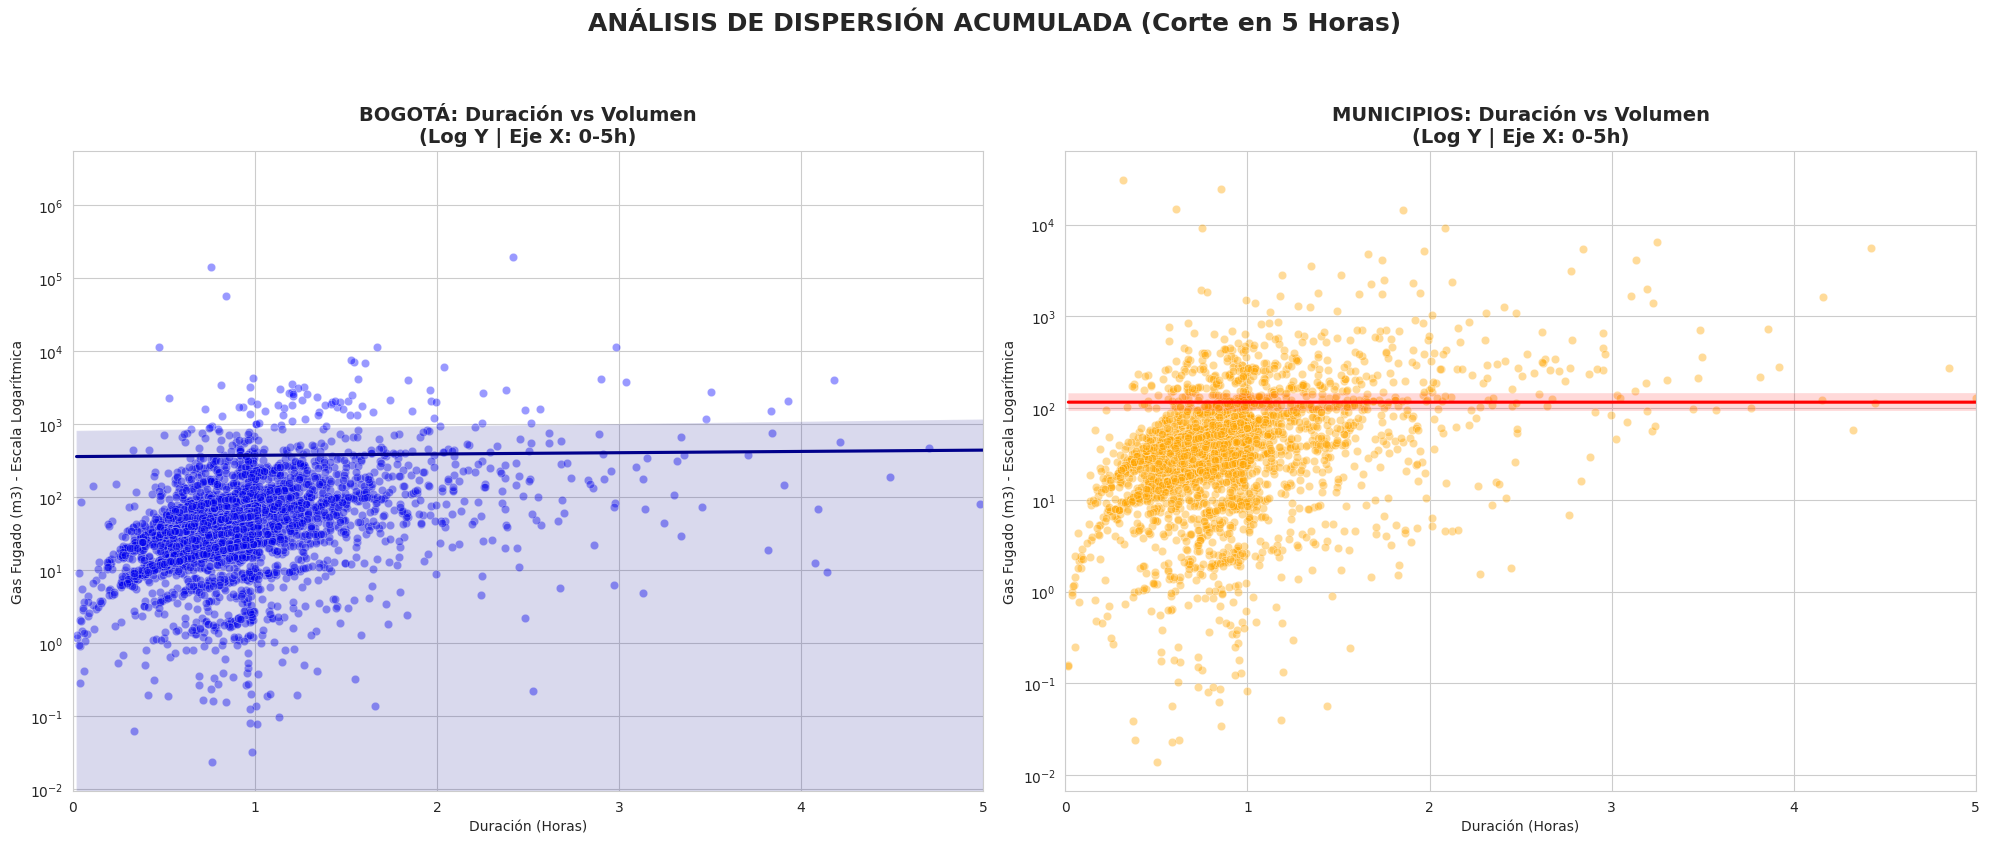

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos la figura
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. SCATTER PLOT BOGOTÁ (Log Y | X limitado a 100)
sns.scatterplot(
    data=df_bogota,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.4,
    color='blue',
    ax=axes[0]
)
# Línea de tendencia (Regplot ignora automáticamente los límites visuales para calcular la línea)
sns.regplot(data=df_bogota, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='darkblue', ax=axes[0])

axes[0].set_yscale('log')
axes[0].set_xlim(0, 5)  # <-- Limitamos el eje X a 100 horas
axes[0].set_title('BOGOTÁ: Duración vs Volumen\n(Log Y | Eje X: 0-5h)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Gas Fugado (m3) - Escala Logarítmica')
axes[0].set_xlabel('Duración (Horas)')

# 2. SCATTER PLOT MUNICIPIOS (Log Y | X limitado a 100)
sns.scatterplot(
    data=df_municipios,
    x='Duracion_Fuga_H',
    y='Gas_Fugado',
    alpha=0.4,
    color='orange',
    ax=axes[1]
)
sns.regplot(data=df_municipios, x='Duracion_Fuga_H', y='Gas_Fugado', scatter=False, color='red', ax=axes[1])

axes[1].set_yscale('log')
axes[1].set_xlim(0, 5)  # <-- Limitamos el eje X a 100 horas
axes[1].set_title('MUNICIPIOS: Duración vs Volumen\n(Log Y | Eje X: 0-5h)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Gas Fugado (m3) - Escala Logarítmica')
axes[1].set_xlabel('Duración (Horas)')

plt.suptitle('ANÁLISIS DE DISPERSIÓN ACUMULADA (Corte en 5 Horas)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 5.4.1 PCA

In [ ]:
df_bogota_clean = df_bogota.fillna(0)
df_bogota_clean

,ID_Original,Archivo_Origen,Municipio,Red_Afectada,Fecha_Entrada,Hora_Entrada,Hora_de_Control,Hora_de_Finalización,Fecha_Hora_de_Control,Fecha_Hora_de_Finalización,...,Hora_Entrada_Clean,Hora_de_Control_Clean,TS_Entrada,TS_Control,Duracion_Fuga_H,Velocidad_Fuga_m3h,Estado_Registro,Momento_Dia,Municipio_Clean,Region
0,0,data_consolidado2.xlsx,BOGOTA DC,Troncal,20250101,10:34:16,11:16:00,16:35:42,20250101,20250101,...,10:34:16,11:16:00,2025-01-01 10:34:16,2025-01-01 11:16:00,0.695556,34.950479,Operativo Estándar,Mañana,BOGOTA DC,Bogotá
1,1,data_consolidado2.xlsx,BOGOTA DC,Anillo,20250101,15:25:10,16:01:00,17:30:22,20250101,20250101,...,15:25:10,16:01:00,2025-01-01 15:25:10,2025-01-01 16:01:00,0.597222,7.350698,Operativo Estándar,Tarde,BOGOTA DC,Bogotá
2,2,data_consolidado2.xlsx,BOGOTA DC,Anillo,20250201,10:09:37,11:27:03,13:19:49,20250201,20250201,...,10:09:37,11:27:03,2025-02-01 10:09:37,2025-02-01 11:27:03,1.290556,74.595781,Operativo Estándar,Mañana,BOGOTA DC,Bogotá
3,3,data_consolidado2.xlsx,BOGOTA DC,Anillo,20250201,10:55:11,12:35:20,15:08:55,20250201,20250201,...,10:55:11,12:35:20,2025-02-01 10:55:11,2025-02-01 12:35:20,1.669167,8.507239,Operativo Estándar,Mañana,BOGOTA DC,Bogotá
4,4,data_consolidado2.xlsx,BOGOTA DC,Anillo,20250201,13:00:19,13:41:10,14:54:08,20250201,20250201,...,13:00:19,13:41:10,2025-02-01 13:00:19,2025-02-01 13:41:10,0.680833,58.839657,Operativo Estándar,Tarde,BOGOTA DC,Bogotá
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10489,5429,data_consolidado.xlsx,BOGOTA DC,Anillo,20240930,11:34:51,12:31:00,13:51:45,20240930,20240930,...,11:34:51,12:31:00,2024-09-30 11:34:51,2024-09-30 12:31:00,0.935833,57.518789,Operativo Estándar,Mañana,BOGOTA DC,Bogotá
10490,5430,data_consolidado.xlsx,BOGOTA DC,Anillo,20240930,12:04:46,13:19:22,14:52:43,20240930,20240930,...,12:04:46,13:19:22,2024-09-30 12:04:46,2024-09-30 13:19:22,1.243333,140.901072,Operativo Estándar,Tarde,BOGOTA DC,Bogotá
10491,5431,data_consolidado.xlsx,BOGOTA DC,Anillo,20240930,14:37:07,15:31:00,16:21:09,20240930,20240930,...,14:37:07,15:31:00,2024-09-30 14:37:07,2024-09-30 15:31:00,0.898056,40.951809,Operativo Estándar,Tarde,BOGOTA DC,Bogotá
10492,5432,data_consolidado.xlsx,BOGOTA DC,Anillo,20240930,15:13:03,16:14:00,17:20:23,20240930,20240930,...,15:13:03,16:14:00,2024-09-30 15:13:03,2024-09-30 16:14:00,1.015833,48.083675,Operativo Estándar,Tarde,BOGOTA DC,Bogotá


In [ ]:
vars_categoricas = [
    # 'Tipo_Rotura',
    # 'Diametro',
    # 'Red_Afectada',
    'Momento_Dia'
]
var_objetivo = [
    # 'Velocidad_Fuga_m3h',
    'Gas_Fugado',
    'Duracion_Fuga_H'
]

df_bogota_obj = df_bogota[var_objetivo + vars_categoricas]

df_bogota_obj_dum = pd.get_dummies(df_bogota_obj, dtype = int)
df_bogota_obj_dum

,Gas_Fugado,Duracion_Fuga_H,Momento_Dia_Madrugada,Momento_Dia_Mañana,Momento_Dia_Noche,Momento_Dia_Tarde
0,24.310,0.695556,0,1,0,0
1,4.390,0.597222,0,0,0,1
2,96.270,1.290556,0,1,0,0
3,14.200,1.669167,0,1,0,0
4,40.060,0.680833,0,0,0,1
...,...,...,...,...,...,...
10489,53.828,0.935833,0,1,0,0
10490,175.187,1.243333,0,0,0,1
10491,36.777,0.898056,0,0,0,1
10492,48.845,1.015833,0,0,0,1


Variables utilizadas:
Index(['Gas_Fugado', 'Duracion_Fuga_H', 'Momento_Dia_Madrugada',
       'Momento_Dia_Mañana', 'Momento_Dia_Noche', 'Momento_Dia_Tarde'],
      dtype='object')

Varianza explicada:
   Componente      Varianza  Varianza acumulada
0           1  3.149781e-01            0.314978
1           2  1.852768e-01            0.500255
2           3  1.808050e-01            0.681060
3           4  1.709055e-01            0.851965
4           5  1.480345e-01            1.000000
5           6  3.052657e-16            1.000000


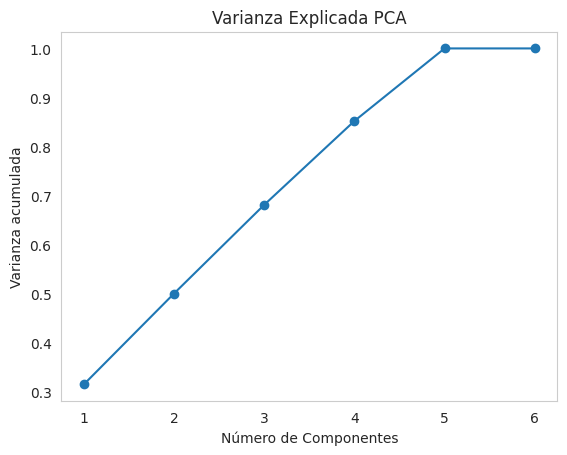


Mejores dimensiones:
Dimensión 1: 1
Dimensión 2: 2


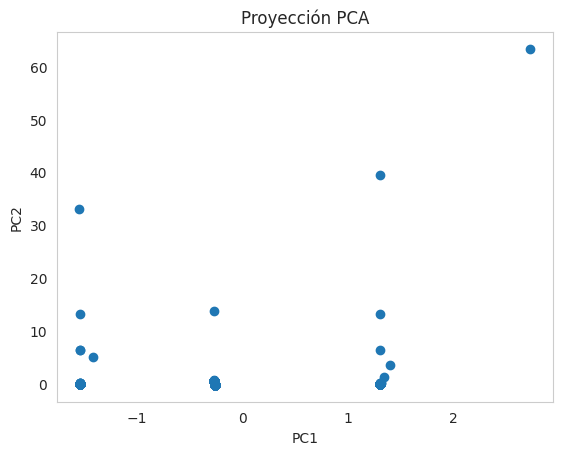


Componentes principales:
       Gas_Fugado  Duracion_Fuga_H  Momento_Dia_Madrugada  Momento_Dia_Mañana  \
PC1  1.752598e-02    -3.226189e-05              -0.019590            0.711073   
PC2  6.995901e-01     7.062594e-01              -0.021056           -0.023806   
PC3 -8.370401e-02    -3.836591e-02               0.420087           -0.197776   
PC4  7.360189e-02     1.793467e-02               0.887086           -0.034191   
PC5 -7.055799e-01     7.066853e-01               0.021336            0.013954   
PC6 -1.818870e-18    -1.503780e-17               0.187947            0.673297   

     Momento_Dia_Noche  Momento_Dia_Tarde  
PC1          -0.028265          -0.702058  
PC2           0.103229          -0.010248  
PC3           0.845194          -0.248153  
PC4          -0.452354          -0.039335  
PC5          -0.045803          -0.002264  
PC6           0.259748           0.666241  


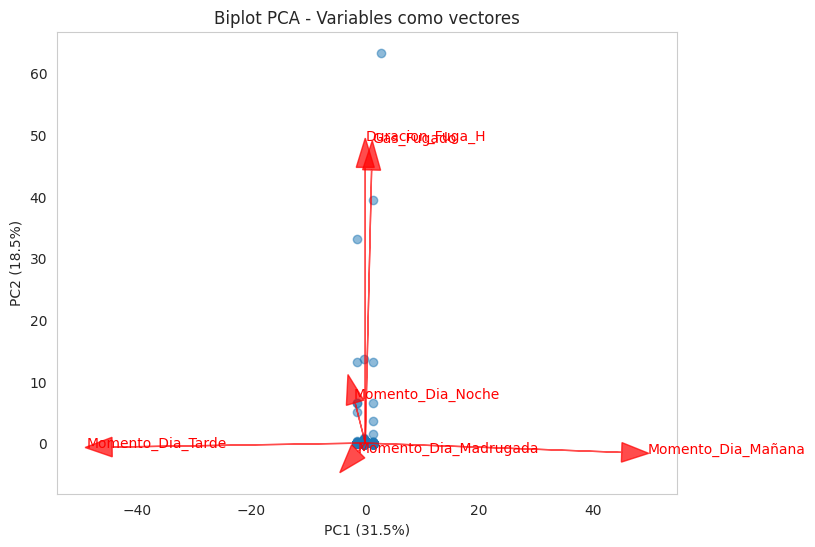


Scores PCA:
        PC1       PC2       PC3       PC4       PC5           PC6
0  1.303015 -0.066503 -0.204603 -0.036627  0.010961  3.098065e-16
1 -1.539449 -0.041025 -0.310552 -0.047830 -0.021932 -7.454249e-16
2  1.303062 -0.059094 -0.205128 -0.036289  0.014612  3.098065e-16
3  1.303008 -0.057707 -0.205063 -0.036424  0.020291  3.098065e-16
4 -1.539426 -0.039319 -0.310706 -0.047712 -0.022090 -7.454249e-16


In [ ]:
# ===============================
# 1. Librerías
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ===============================
# 2. Cargar datos
# ===============================
# Cambia por tu archivo
df = df_bogota_obj_dum

# Mantener solo variables numéricas
X = df.select_dtypes(include=[np.number])

# --- LÍNEA DE CORRECCIÓN ---
X = X.dropna() # Esto elimina cualquier fila que tenga un vacío
# ---------------------------

print("Variables utilizadas:")
print(X.columns)


# ===============================
# 3. Estandarización
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ===============================
# 4. PCA
# ===============================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
scores = pca.transform(X_scaled)


# ===============================
# 5. Varianza explicada
# ===============================
varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

tabla_varianza = pd.DataFrame({
    "Componente": np.arange(1, len(varianza)+1),
    "Varianza": varianza,
    "Varianza acumulada": varianza_acum
})

print("\nVarianza explicada:")
print(tabla_varianza)


# ===============================
# 6. Scree Plot
# ===============================
plt.figure()

plt.plot(range(1,len(varianza)+1),
         varianza_acum,
         marker='o')

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza Explicada PCA")

plt.grid()

plt.show()


# ===============================
# 7. Selección mejores dimensiones
# ===============================

# Ordenar componentes por varianza
indices_mejores = np.argsort(varianza)[::-1]

dim1 = indices_mejores[0]
dim2 = indices_mejores[1]

print("\nMejores dimensiones:")
print("Dimensión 1:", dim1+1)
print("Dimensión 2:", dim2+1)


# ===============================
# 8. Representación datos PCA
# ===============================

plt.figure()

plt.scatter(
    X_pca[:,dim1],
    X_pca[:,dim2]
)

plt.xlabel(f"PC{dim1+1}")
plt.ylabel(f"PC{dim2+1}")

plt.title("Proyección PCA")

plt.grid()

plt.show()


# ===============================
# 9. Componentes principales
# ===============================

componentes = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(len(X.columns))]
)

print("\nComponentes principales:")
print(componentes)



# =====================
# Selección PC1 y PC2
# =====================
pc1 = 0
pc2 = 1


# =====================
# Loadings (Vectores)
# =====================
loadings = pca.components_.T

# Escala para vectores
scale = np.max(np.abs(scores[:,[pc1,pc2]]))


# =====================
# Biplot
# =====================
plt.figure(figsize=(8,6))

# Puntos
plt.scatter(
    scores[:,pc1],
    scores[:,pc2],
    alpha=0.5
)

# Vectores variables
for i, var in enumerate(X.columns):

    x = loadings[i,pc1] * scale
    y = loadings[i,pc2] * scale

    plt.arrow(
        0,0,
        x,y,
        color='red',
        alpha=0.7,
        head_width=0.05*scale
    )

    plt.text(
        x*1.1,
        y*1.1,
        var,
        color='red'
    )


plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.title("Biplot PCA - Variables como vectores")

plt.grid()

plt.show()



# ===============================
# 11. Scores PCA
# ===============================

scores = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(len(X.columns))]
)

print("\nScores PCA:")
print(scores.head())